# Distributional Robustness in Games via Coherent Risk Measures

This notebook explores mixed complementarity problem (MCP) solvers and related game-theoretic models, with visualizations and numerical experiments. It includes plotting utilities, linear and complementarity formulations, and example games to compare solver behavior.


## Requirements

In [12]:
# Python requirements
!pip -q install numpy matplotlib pandas pyomo scipy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### Solver
This notebook requires the `PATH` or `ipopt` solver to run the complementarity programmes. 

`PATH`: https://pages.cs.wisc.edu/~ferris/path.html
`ipopt`: https://coin-or.github.io/Ipopt/

If neither are available, the Fischer-Burmeister optimisation implementation can also be used 

## Instructions

1. Run the requirements cell if your environment is fresh.
2. Execute the notebook top-to-bottom to reproduce figures and experiments.
3. Re-run individual sections as needed when adjusting parameters.
4. If a solver backend is missing, install it and re-run the affected section.


## Table of Contents

1. Graphs (Fig 1, Fig 2)
1. Zero-Sum Linear Program
1. Pyomo Complementarity (MSD, CVaR)
1. Fischer-Burmeister (FB) NCP Solver
1. Experiments (Coordination game; Prisoner's Dilemma; Fig 3; Non zero-sum game; Fig 4)


# Graphs

## Fig 1

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_36764/3202981807.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel(r'$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$', labelpad=10)


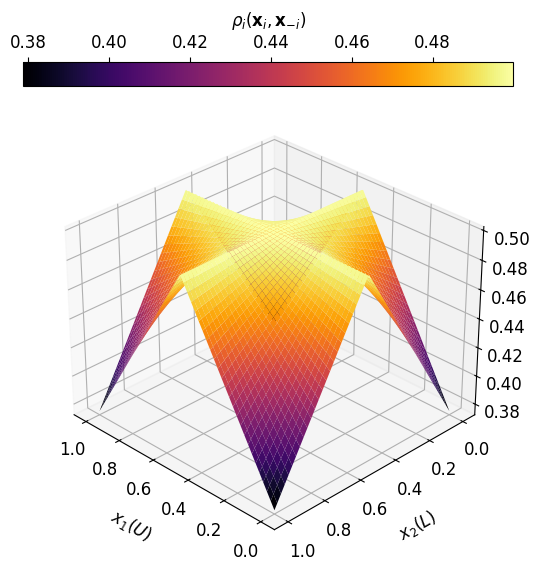

In [1]:
"""import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # noqa: F401

# Global font size
plt.rcParams.update({
"font.size": 12,
"axes.labelsize": 12,
"xtick.labelsize": 12,
"ytick.labelsize": 12,
})

# Strategy grids
x1 = np.linspace(0, 1, 200)
x2 = np.linspace(0, 1, 200)
X1, X2 = np.meshgrid(x1, x2)

# Ambiguity set
p_min, p_max = 0.3, 0.7
term = (1 - 2*X1) * (1 - 2*X2)

rho_pmin = 0.5 + 0.5 * (2*p_min - 1) * term
rho_pmax = 0.5 + 0.5 * (2*p_max - 1) * term
rho = np.minimum(rho_pmin, rho_pmax)

# Figure
fig = plt.figure(figsize=(7, 6))

# Main 3D plot
ax = fig.add_axes([0.05, 0.05, 0.9, 0.75], projection='3d')
surf = ax.plot_surface(X1, X2, rho, cmap='inferno', linewidth=0)

ax.set_xlabel(r'$x_1(U)$', labelpad=10)
ax.set_ylabel(r'$x_2(L)$', labelpad=10)
ax.set_zlabel(r'$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$', labelpad=10)
ax.view_init(elev=30, azim=135)

# Horizontal colorbar above the plot
cax = fig.add_axes([0.15, 0.83, 0.7, 0.04])
cbar = fig.colorbar(surf, cax=cax, orientation='horizontal')

# Move ticks and label to the top
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.set_label(r'$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$', labelpad=6)

plt.show()
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Global font size (≈12 px)
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

# Strategy grids
x1 = np.linspace(0, 1, 200)  # x_1(U)
x2 = np.linspace(0, 1, 200)  # x_2(L)
X1, X2 = np.meshgrid(x1, x2)

# Parameter
gamma_s = 0.5

# Utility
rho = 0.5 - (gamma_s / 4.0) * np.abs((1 - 2 * X1) * (1 - 2 * X2))

# Figure
fig = plt.figure(figsize=(7, 6))

# Main 3D axes (leave room on top)
ax = fig.add_axes([0.05, 0.05, 0.9, 0.75], projection="3d")

surf = ax.plot_surface(X1, X2, rho, cmap="inferno", linewidth=0, antialiased=True)

# Horizontal colorbar above the plot
cax = fig.add_axes([0.15, 0.83, 0.7, 0.04])
cbar = fig.colorbar(surf, cax=cax, orientation="horizontal")

# Put ticks and label above the bar
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
cbar.set_label(r"$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$", labelpad=6)

# Axis labels
ax.set_xlabel(r"$x_1(U)$", labelpad=10)
ax.set_ylabel(r"$x_2(L)$", labelpad=10)
ax.set_zlabel(r"$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$", labelpad=10)

# Camera angle
ax.view_init(elev=30, azim=135)

plt.show()

## Fig 2

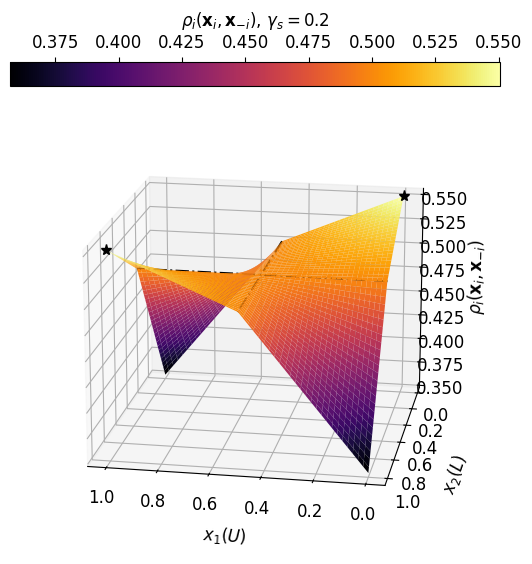

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Global font size (≈12 px)
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

# Strategy grids
x1 = np.linspace(0, 1, 200)  # x_1(U)
x2 = np.linspace(0, 1, 200)  # x_2(L)
X1, X2 = np.meshgrid(x1, x2)

# Parameter
gamma_s = 0.2
p = 0.6

# Utility
rho_func = lambda X1, X2, p, gamma_s: (
    0.5
    + (2 * p - 1) / 2 * (1 - 2 * X1) * (1 - 2 * X2)
    - gamma_s * (1 - p) * p * np.abs((1 - 2 * X1) * (1 - 2 * X2))
)
rho = rho_func(X1, X2, p, gamma_s)

# Figure
fig = plt.figure(figsize=(7, 6))

# Main 3D axes (leave room on top)
ax = fig.add_axes([0.05, 0.05, 0.9, 0.75], projection="3d")

surf = ax.plot_surface(X1, X2, rho, cmap="inferno", linewidth=0, antialiased=True)

# Horizontal colorbar above the plot
cax = fig.add_axes([0.15, 0.83, 0.7, 0.04])
cbar = fig.colorbar(surf, cax=cax, orientation="horizontal")

# Add dashed lines at x1=0.5 and x2=0.5
nval = rho_func(0, 0.5, p, gamma_s)
ax.plot([0.5, 0.5], [0, 1], [nval, nval], "k-.", linewidth=1.5, zorder=2)
ax.plot([0, 1], [0.5, 0.5], [nval, nval], "k-.", linewidth=1.5, zorder=2)

# Add points at pure Nash
pureval = rho_func(1, 1, p, gamma_s)
ax.plot([1], [1], [pureval], "k*", markersize=8, zorder=4)
ax.plot([0], [0], [pureval], "k*", markersize=8, zorder=4)

# Put ticks and label above the bar
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
cbar.set_label(r"$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$, $\gamma_s=0.2$", labelpad=6)

# Axis labels
ax.set_xlabel(r"$x_1(U)$", labelpad=10)
ax.set_ylabel(r"$x_2(L)$", labelpad=10)
ax.set_zlabel(r"$\rho_i(\mathbf{x}_i,\mathbf{x}_{-i})$", labelpad=10)

# Camera angle
# elev=17.5, azim=100
ax.view_init(elev=17.5, azim=100)

plt.show()

# Zero-Sum Linear Program

In [5]:
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition


def build_linear_zero_sum_model(
    A_bar: np.ndarray,
) -> pyo.ConcreteModel:

    model = pyo.ConcreteModel()

    # Sets
    model.I = pyo.RangeSet(0, A_bar.shape[0] - 1)
    model.J = pyo.RangeSet(0, A_bar.shape[1] - 1)

    # Parameters
    model.A_bar = pyo.Param(
        model.I,
        model.J,
        initialize={(i, j): A_bar[i, j] for i in model.I for j in model.J},
        domain=pyo.Reals,
    )

    # Variables
    model.x = pyo.Var(model.I, domain=pyo.NonNegativeReals)
    model.pi1 = pyo.Var(domain=pyo.Reals)

    # Objective
    model.obj = pyo.Objective(
        expr=model.pi1,
        sense=pyo.maximize,
    )

    # Constraints
    model.game_value = pyo.Constraint(
        model.J,
        rule=lambda m, j: sum(model.x[i] * m.A_bar[i, j] for i in model.I) >= m.pi1,
    )
    model.simplex_x = pyo.Constraint(expr=sum(model.x[i] for i in model.I) == 1.0)

    # import duals for constraints
    model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)

    return model


def solve_model(m: pyo.ConcreteModel, solver: str = "cbc"):
    opt = pyo.SolverFactory(solver, executable="/opt/homebrew/bin/cbc")
    if opt.available(exception_flag=False):
        res = opt.solve(m, tee=False)
        return res
    raise Exception


def build_and_solve(A_bar):
    x_mod = build_linear_zero_sum_model(A_bar)
    solve_model(x_mod)

    # Column strategy y = duals of col constraints
    y = np.array([x_mod.dual[x_mod.game_value[j]] for j in x_mod.J])
    # numerical tidy
    y = np.maximum(y, 0)
    s = y.sum()
    if s > 0:
        y /= s

    # extract
    x = np.array([pyo.value(x_mod.x[i]) for i in x_mod.I])
    y = np.array([pyo.value(y[i]) for i in range(len(y))])

    return {
        "x": x,
        "y": y,
        "game_value": pyo.value(x_mod.obj),
    }

In [7]:
A1 = np.array([[0.5, 2], [1, 5]]) * 4
A2 = np.array([[-1, 7], [-1, -10]]) * 4
A_list = [A1, A2]

p = 0.5
p = np.array([p, 1 - p])

A_bar = np.array(sum([pk * A for pk, A in zip(p, A_list)]))

print("A_bar =\n", A_bar)

res = build_and_solve(A_bar)
print("x* =", res["x"], " y* =", res["y"], " game value =", res["game_value"])

A_bar =
 [[ -1.  18.]
 [  0. -10.]]
x* = [0.34482759 0.65517241]  y* = [0.96551724 0.03448276]  game value = -0.34482759


# Pyomo Complementarity

In [1]:
import numpy as np


def simulate_random_payoffs(
    K: int, n: int, seed: int | None = None, dist: str = "uniform", **kwargs
):
    """
    Simulate K payoff matrices (n x n) for two players.

    Args:
        K: number of scenarios / samples.
        n: action space size for each player (square payoff matrices).
        seed: RNG seed.
        dist: 'uniform' or 'normal'.
        kwargs: extra params: for 'uniform' use low, high; for 'normal' use loc, scale.

    Returns:
        A_list, B_list, p  -- lists of K numpy arrays (shape (n,n)) and scenario probabilities (length K).
    """
    rng = np.random.default_rng(seed)
    if dist == "uniform":
        low = kwargs.get("low", 0.0)
        high = kwargs.get("high", 1.0)
        A_list = [rng.uniform(low, high, (n, n)) for _ in range(K)]
        B_list = [rng.uniform(low, high, (n, n)) for _ in range(K)]
    elif dist == "normal":
        loc = kwargs.get("loc", 0.0)
        scale = kwargs.get("scale", 1.0)
        A_list = [rng.normal(loc, scale, (n, n)) for _ in range(K)]
        B_list = [rng.normal(loc, scale, (n, n)) for _ in range(K)]
    else:
        raise ValueError("Unsupported dist. Choose 'uniform' or 'normal'.")

    p = rng.dirichlet(np.ones(K))
    return A_list, B_list, p

## MSD

In [27]:
# Two-player mean-semi-deviation (MSD) risk-aware bimatrix game as a Multilinear Complementarity Problem (MCP)
# Requires: pyomo (>=6), plus PATH ('path' or 'pathmcp') or IPOPT with mpec.simple_nonlinear transform.

import time
import tempfile
from typing import List
import numpy as np
import pyomo.environ as pyo
from pyomo.mpec import Complementarity, complements
from pyomo.opt import SolverStatus, TerminationCondition


def build_model(
    A_list: List[np.ndarray], B_list: List[np.ndarray], p: np.ndarray, gamma: float
) -> pyo.ConcreteModel:
    K = len(A_list)
    n1, n2 = A_list[0].shape
    assert all(Ak.shape == (n1, n2) for Ak in A_list)
    assert all(Bk.shape == (n1, n2) for Bk in B_list)
    p = np.asarray(p, dtype=float)
    p = p / p.sum()

    m = pyo.ConcreteModel()

    # Sets
    m.I = pyo.RangeSet(0, n1 - 1)
    m.J = pyo.RangeSet(0, n2 - 1)
    m.K = pyo.RangeSet(0, K - 1)

    # Params (store as dicts for Pyomo)
    # Converts payoff matrices to 3D arrays
    def to_param_3d(lst):
        data = {}
        for k, M in enumerate(lst):
            for i in range(n1):
                for j in range(n2):
                    data[(k, i, j)] = float(M[i, j])
        return data

    m.p = pyo.Param(
        m.K, initialize={k: float(p[k]) for k in range(K)}, within=pyo.NonNegativeReals
    )
    m.gamma = pyo.Param(initialize=float(gamma), within=pyo.NonNegativeReals)
    m.A = pyo.Param(m.K, m.I, m.J, initialize=to_param_3d(A_list))
    m.B = pyo.Param(m.K, m.I, m.J, initialize=to_param_3d(B_list))

    # Abar, Bbar
    def Abar_rule(m, i, j):
        return sum(m.p[k] * m.A[k, i, j] for k in m.K)

    def Bbar_rule(m, i, j):
        return sum(m.p[k] * m.B[k, i, j] for k in m.K)

    m.Abar = pyo.Param(
        m.I,
        m.J,
        initialize={(i, j): Abar_rule(m, i, j) for i in range(n1) for j in range(n2)},
    )
    m.Bbar = pyo.Param(
        m.I,
        m.J,
        initialize={(i, j): Bbar_rule(m, i, j) for i in range(n1) for j in range(n2)},
    )

    # Initial point: PATH is much more reliable if the simplex variables
    # start feasible instead of at Pyomo's default zero values.
    x0 = np.ones(n1) / n1
    y0 = np.ones(n2) / n2
    Abar_np = sum(float(pk) * Ak for pk, Ak in zip(p, A_list))
    Bbar_np = sum(float(pk) * Bk for pk, Bk in zip(p, B_list))
    alpha1_0 = float(x0 @ Abar_np @ y0)
    alpha2_0 = float(x0 @ Bbar_np @ y0)

    # Variables
    m.x = pyo.Var(
        m.I, domain=pyo.NonNegativeReals, initialize=lambda m, i: x0[i]
    )  # strategies
    m.y = pyo.Var(m.J, domain=pyo.NonNegativeReals, initialize=lambda m, j: y0[j])
    m.alpha1 = pyo.Var(domain=pyo.Reals, initialize=alpha1_0)  # values
    m.alpha2 = pyo.Var(domain=pyo.Reals, initialize=alpha2_0)
    m.lam1 = pyo.Var(
        m.K,
        bounds=lambda m, k: (0.0, pyo.value(m.gamma) * pyo.value(m.p[k])),
        initialize=lambda m, k: 0.5 * pyo.value(m.gamma) * pyo.value(m.p[k]),
    )
    m.lam2 = pyo.Var(
        m.K,
        bounds=lambda m, k: (0.0, pyo.value(m.gamma) * pyo.value(m.p[k])),
        initialize=lambda m, k: 0.5 * pyo.value(m.gamma) * pyo.value(m.p[k]),
    )
    m.z1 = pyo.Var(m.K, domain=pyo.NonNegativeReals, initialize=1e-6)  # z >= 0
    m.z2 = pyo.Var(m.K, domain=pyo.NonNegativeReals, initialize=1e-6)

    # Non-zero solution constraint to avoid trivial all-zero solution if using the non-simplex formulation
    # m.nonzero_x = pyo.Constraint(expr=sum(m.x[i] for i in m.I) >= 1e-6)
    # m.nonzero_y = pyo.Constraint(expr=sum(m.y[j] for j in m.J) >= 1e-6)
    # m.nonzero_z1 = pyo.Constraint(expr=sum(m.z1[k] for k in m.K) >= 1e-6)
    # m.nonzero_z2 = pyo.Constraint(expr=sum(m.z2[k] for k in m.K) >= 1e-6)

    # Simplex equalities
    m.simplex_x = pyo.Constraint(expr=sum(m.x[i] for i in m.I) == 1.0)
    m.simplex_y = pyo.Constraint(expr=sum(m.y[j] for j in m.J) == 1.0)

    # Helper expressions
    # Player 1 row values: v1[i] = Abar[i,:] y + sum_k lam1[k]*(A^k - Abar)[i,:] y
    def v1_rule(m, i):
        base = sum(m.Abar[i, j] * m.y[j] for j in m.J)
        dev = sum(
            m.lam1[k] * sum((m.A[k, i, j] - m.Abar[i, j]) * m.y[j] for j in m.J)
            for k in m.K
        )
        return base + dev

    m.v1 = pyo.Expression(m.I, rule=v1_rule)

    # Player 2 column values: v2[j] = x^T Bbar[:,j] + sum_k lam2[k]* x^T (B^k - Bbar)[:,j]
    def v2_rule(m, j):
        base = sum(m.x[i] * m.Bbar[i, j] for i in m.I)
        dev = sum(
            m.lam2[k] * sum(m.x[i] * (m.B[k, i, j] - m.Bbar[i, j]) for i in m.I)
            for k in m.K
        )
        return base + dev

    m.v2 = pyo.Expression(m.J, rule=v2_rule)

    # Scenario residuals:
    # r1[k] = x^T (A^k - Abar) y
    def r1_rule(m, k):
        return sum(
            m.x[i] * sum((m.A[k, i, j] - m.Abar[i, j]) * m.y[j] for j in m.J)
            for i in m.I
        )

    m.r1 = pyo.Expression(m.K, rule=r1_rule)

    # r2[k] = x^T (B^k - Bbar) y
    def r2_rule(m, k):
        return sum(
            m.x[i] * sum((m.B[k, i, j] - m.Bbar[i, j]) * m.y[j] for j in m.J)
            for i in m.I
        )

    m.r2 = pyo.Expression(m.K, rule=r2_rule)

    # Complementarity conditions
    # 0 <= x_i ⟂ alpha1 - v1_i >= 0
    m.comp_x = Complementarity(
        m.I, rule=lambda m, i: complements(m.x[i] >= 0, m.alpha1 - m.v1[i] >= 0)
    )
    # 0 <= y_j ⟂ alpha2 - v2_j >= 0
    m.comp_y = Complementarity(
        m.J, rule=lambda m, j: complements(m.y[j] >= 0, m.alpha2 - m.v2[j] >= 0)
    )
    # 0 <= lam1_k ⟂ r1_k + z1_k >= 0 ; 0 <= gamma p_k - lam1_k ⟂ z1_k >= 0
    m.comp_r1 = Complementarity(
        m.K, rule=lambda m, k: complements(m.lam1[k] >= 0, m.r1[k] + m.z1[k] >= 0)
    )
    m.comp_z1 = Complementarity(
        m.K,
        rule=lambda m, k: complements(m.gamma * m.p[k] - m.lam1[k] >= 0, m.z1[k] >= 0),
    )
    # Player 2 analogues
    m.comp_r2 = Complementarity(
        m.K, rule=lambda m, k: complements(m.lam2[k] >= 0, m.r2[k] + m.z2[k] >= 0)
    )
    m.comp_z2 = Complementarity(
        m.K,
        rule=lambda m, k: complements(m.gamma * m.p[k] - m.lam2[k] >= 0, m.z2[k] >= 0),
    )

    return m


def solve_model(
    m: pyo.ConcreteModel,
    solver: str = "pathampl",
    fallback_solver: str | None = None,
    tee: bool = False,
    path_options: dict | None = None,
):

    if path_options is None:
        path_options = {
            "major_iteration_limit": 500,
            "minor_iteration_limit": 10_000,
            "cumulative_iteration_limit": 100_000,
            "time_limit": 60,
            "nms_memory_size": 50,
            "restart_limit": 10,
            "convergence_tolerance": 1e-8,
        }

    def make_path_optfile(options):
        if not options:
            return None
        optfile = tempfile.NamedTemporaryFile(
            mode="w", prefix="path_", suffix=".opt", delete=False
        )
        with optfile:
            for key, value in options.items():
                optfile.write(f"{key} {value}\n")
        return optfile.name

    def solve_and_load(opt, model, solver_options=None):
        try:
            res = opt.solve(
                model,
                tee=tee,
                load_solutions=False,
                options=solver_options or {},
            )
        except Exception as exc:
            print("Solver raised an exception:", exc)
            raise

        if (
            res.solver.status != SolverStatus.ok
            or res.solver.termination_condition != TerminationCondition.optimal
        ):
            print("Solver status:", res.solver.status)
            print("Termination condition:", res.solver.termination_condition)
            if hasattr(res.solver, "message"):
                print("Solver message:", res.solver.message)
                print("Solver result object:", res)

        try:
            model.solutions.load_from(res)
        except Exception as exc:
            print("Failed to load solutions from solver result:", exc)
            print("Solver result object:", res)
            raise
        return res

    def transform_and_solve(model):
        transformed_model = model.clone()
        pyo.TransformationFactory("mpec.simple_nonlinear").apply_to(transformed_model)
        opt = pyo.SolverFactory("ipopt")
        assert opt.available(exception_flag=False), "Neither PATH nor IPOPT available."
        res = solve_and_load(opt, transformed_model)
        return res, transformed_model

    opt = pyo.SolverFactory(solver)
    start = time.perf_counter()
    if solver == "ipopt":
        res, solved_model = transform_and_solve(m)
        elapsed = time.perf_counter() - start
        return res, elapsed, solved_model

    if opt.available(exception_flag=False):
        fallback_model = m.clone()
        solver_options = {}
        if solver == "pathampl":
            path_optfile = make_path_optfile(path_options)
            if path_optfile is not None:
                solver_options["optfile"] = path_optfile
        try:
            res = solve_and_load(opt, m, solver_options=solver_options)
            solved_model = m
        except Exception as e:
            if fallback_solver != "ipopt":
                raise
            res, solved_model = transform_and_solve(fallback_model)
            print(f"Solved using ipopt because {e}")

        elapsed = time.perf_counter() - start
        return res, elapsed, solved_model

    if fallback_solver != "ipopt":
        raise RuntimeError(
            f"Solver {solver!r} is not available and fallback_solver={fallback_solver!r}."
        )
    res, solved_model = transform_and_solve(m)
    elapsed = time.perf_counter() - start
    return res, elapsed, solved_model


def msd_problem_stats(A_list, B_list):
    K = len(A_list)
    n1, n2 = A_list[0].shape
    n_vars = n1 + n2 + 4 * K + 2
    n_complementarities = n1 + n2 + 4 * K
    n_equalities = 2
    n_payoff_entries = K * n1 * n2 * 2
    return {
        "K": K,
        "n1": n1,
        "n2": n2,
        "variables": n_vars,
        "complementarities": n_complementarities,
        "equalities": n_equalities,
        "payoff_entries": n_payoff_entries,
    }


def warn_large_path_instance(A_list, B_list, solver):
    if solver != "pathampl":
        return
    stats = msd_problem_stats(A_list, B_list)
    if stats["payoff_entries"] >= 200_000:
        print(
            "WARNING: Large Pyomo/ASL instance: "
            f"K={stats['K']}, n1={stats['n1']}, n2={stats['n2']}, "
            f"payoff_entries={stats['payoff_entries']}. "
            "For K in the thousands, the Pyomo MCP route can become the bottleneck."
        )


def build_and_solve(
    A_list,
    B_list,
    p,
    gamma,
    solver="pathampl",
    fallback_solver=None,
    tee=False,
    path_options=None,
):
    warn_large_path_instance(A_list, B_list, solver)
    m = build_model(A_list, B_list, p, gamma)
    res, solve_time, m = solve_model(
        m,
        solver=solver,
        fallback_solver=fallback_solver,
        tee=tee,
        path_options=path_options,
    )
    # extract
    x = np.array([pyo.value(m.x[i]) for i in m.I])
    y = np.array([pyo.value(m.y[j]) for j in m.J])
    alpha1 = float(pyo.value(m.alpha1))
    alpha2 = float(pyo.value(m.alpha2))
    lam1 = np.array([pyo.value(m.lam1[k]) for k in m.K])
    lam2 = np.array([pyo.value(m.lam2[k]) for k in m.K])
    z1 = np.array([pyo.value(m.z1[k]) for k in m.K])
    z2 = np.array([pyo.value(m.z2[k]) for k in m.K])
    return {
        "x": x,
        "y": y,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "lam1": lam1,
        "z1": z1,
        "lam2": lam2,
        "z2": z2,
        "time": solve_time,
        "model": m,
    }


def path_MCP_game_result(
    A_payoffs,
    B_payoffs,
    gamma,
    p=None,
    verbose=False,
    solver="pathampl",
    fallback_solver=None,
    tee=False,
    path_options=None,
):

    if p is None:
        p = 1 / len(A_payoffs)
        p = np.array([p for _ in range(len(A_payoffs))])

    res = build_and_solve(
        A_payoffs,
        B_payoffs,
        p,
        gamma,
        solver=solver,
        fallback_solver=fallback_solver,
        tee=tee,
        path_options=path_options,
    )

    if verbose:

        print("=" * 50 + "PATH Result" + "=" * 50)

        print("x* =", res["x"].round(3), " y* =", res["y"].round(3))
        print("alpha1 =", res["alpha1"], " alpha2 =", res["alpha2"])

        print(f"{p=}")

        A_bar = np.array(sum([pk * A for pk, A in zip(p, A_payoffs)]))
        B_bar = np.array(sum([pk * B for pk, B in zip(p, B_payoffs)]))

        dev1 = [(A - A_bar) for A in A_payoffs]
        dev2 = [(B - B_bar) for B in B_payoffs]

        print("-" * 50 + "Player 1" + "-" * 50)
        print("A_bar =\n", A_bar)
        print("lam1 =", res["lam1"], " z1 =", res["z1"])
        print(f"x@dev1@y = {np.round(res["x"]@np.stack(dev1)@res["y"], 3)}")
        print(
            "(A_bar + sum(lam1k*dk)) =\n",
            (A_bar + sum(lam * dk for lam, dk in zip(res["lam1"], dev1))),
        )
        print(
            "(A_bar + sum(lam1k*dk))@y =\n",
            (A_bar + sum(lam * dk for lam, dk in zip(res["lam1"], dev1))) @ res["y"],
        )

        print("-" * 50 + "Player 2" + "-" * 50)
        print("B_bar =\n", B_bar)
        print("lam2 =", res["lam2"], " z2 =", res["z2"])
        print(f"x@dev2@y = {np.round(res["x"]@np.stack(dev2)@res["y"], 3)}")
        print(
            "(B_bar + sum(lam2k*dk)) =\n",
            (B_bar + sum(lam * dk for lam, dk in zip(res["lam2"], dev2))),
        )
        print(
            "x@(B_bar + sum(lam2k*dk)) =\n",
            res["x"] @ (B_bar + sum(lam * dk for lam, dk in zip(res["lam2"], dev2))),
        )

    return res

In [25]:
import os

os.environ["PATH_LICENSE_STRING"] = (
    "1259252040&Courtesy&&&USR&GEN2035&5_1_2026&1000&PATH&GEN&31_12_2035&0_0_0&6000&0_0"
)


A_list, B_list, p = simulate_random_payoffs(
    K=5, n=3, seed=42, dist="uniform", low=0, high=1
)

gamma = 0.5
out = path_MCP_game_result(
    A_list, B_list, gamma, p, verbose=True, tee=False, fallback_solver=None
)

==================================================PATH Result==================================================
x* = [0.417 0.583 0.   ]  y* = [1. 0. 0.]
alpha1 = 0.5450861784071849  alpha2 = 0.5913714654384339
p=array([0.04768291, 0.48844449, 0.32896382, 0.08383317, 0.05107562])
--------------------------------------------------Player 1--------------------------------------------------
A_bar =
 [[0.53946174 0.44706748 0.81184883]
 [0.56101805 0.82912577 0.62675279]
 [0.47017014 0.42771348 0.24920651]]
lam1 = [0.         0.         0.12790907 0.04191659 0.02553781]  z1 = [0.        0.        0.        0.0998663 0.       ]
x@dev1@y = [ 0.177  0.011 -0.    -0.1   -0.108]
(A_bar + sum(lam1k*dk)) =
 [[0.54508618 0.45913819 0.78463537]
 [0.54508618 0.84302457 0.65346875]
 [0.51129003 0.39670928 0.28941459]]
(A_bar + sum(lam1k*dk))@y =
 [0.54508618 0.54508618 0.51129003]
--------------------------------------------------Player 2--------------------------------------------------
B_bar =
 [[0.

In [60]:
A_bar = sum(pk * A for pk, A in zip(p, A_list))
B_bar = sum(pk * B for pk, B in zip(p, B_list))

d1 = np.array([out["x"] @ (A - A_bar) @ out["y"] for A in A_list])
d2 = np.array([out["x"] @ (B - B_bar) @ out["y"] for B in B_list])

print("d1:", d1)
print("z1:", out["z1"])
print("expected z1:", np.maximum(0, -d1))
print("z1 error:", out["z1"] - np.maximum(0, -d1))

print("d2:", d2)
print("z2:", out["z2"])
print("expected z2:", np.maximum(0, -d2))
print("z2 error:", out["z2"] - np.maximum(0, -d2))

d1: [ 1.77319460e-01  1.10793792e-02 -9.87394254e-17 -9.98663044e-02
 -1.07578926e-01]
z1: [0.        0.        0.        0.0998663 0.       ]
expected z1: [0.00000000e+00 0.00000000e+00 9.87394254e-17 9.98663044e-02
 1.07578926e-01]
z1 error: [ 0.00000000e+00  0.00000000e+00 -9.87394254e-17 -5.55111512e-17
 -1.07578926e-01]
d2: [ 0.12777688  0.01993159  0.03935441 -0.08559042 -0.42288495]
z2: [0.         0.         0.         0.         0.42288495]
expected z2: [0.         0.         0.         0.08559042 0.42288495]
z2 error: [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -8.55904241e-02
 -1.66533454e-16]


### Small-support search with sparse-witness screening

In [4]:
import contextlib
import io
from itertools import combinations
from math import comb
from time import perf_counter

import numpy as np
from scipy.optimize import minimize


def _as_payoff_arrays(A_list, B_list, p):
    A = np.asarray(A_list, dtype=float)
    B = np.asarray(B_list, dtype=float)
    p = np.asarray(p, dtype=float)
    p = p / p.sum()
    if A.shape != B.shape:
        raise ValueError("A_list and B_list must have the same shape.")
    if A.ndim != 3:
        raise ValueError("Expected payoff arrays with shape (K, n1, n2).")
    if len(p) != A.shape[0]:
        raise ValueError("p must have length K.")
    return A, B, p


def msd_value_from_state_payoffs(state_payoffs, p, gamma):
    """MSD payoff rho = mean + gamma * E[min(0, payoff - mean)]."""
    state_payoffs = np.asarray(state_payoffs, dtype=float)
    mean = float(p @ state_payoffs)
    downside = np.minimum(0.0, state_payoffs - mean)
    return mean + gamma * float(p @ downside)


def msd_profile_values(A_list, B_list, p, gamma, x, y):
    A, B, p = _as_payoff_arrays(A_list, B_list, p)
    u1_states = np.einsum("i,kij,j->k", x, A, y)
    u2_states = np.einsum("i,kij,j->k", x, B, y)
    return {
        "rho1": msd_value_from_state_payoffs(u1_states, p, gamma),
        "rho2": msd_value_from_state_payoffs(u2_states, p, gamma),
        "u1_states": u1_states,
        "u2_states": u2_states,
    }


def _simplex_starts(dim, rng, n_random):
    starts = [np.ones(dim) / dim]
    starts.extend(rng.dirichlet(np.ones(dim), size=n_random))
    return starts


def _maximize_on_simplex(objective, dim, rng, n_starts=20, maxiter=1000):
    best = None
    constraints = [{"type": "eq", "fun": lambda v: np.sum(v) - 1.0}]
    bounds = [(0.0, 1.0)] * dim

    for start in _simplex_starts(dim, rng, max(0, n_starts - 1)):
        res = minimize(
            lambda v: -objective(v),
            start,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": maxiter, "disp": False},
        )
        value = objective(res.x)
        if best is None or value > best["value"]:
            best = {"value": float(value), "strategy": res.x, "result": res}
    return best


def full_msd_regret(A_list, B_list, p, gamma, x, y, n_starts=20, seed=0):
    """Compute eta_K(x) = max_i max_dev rho_i(dev, x_-i) - rho_i(x)."""
    A, B, p = _as_payoff_arrays(A_list, B_list, p)
    rng = np.random.default_rng(seed)
    K, n1, n2 = A.shape
    base = msd_profile_values(A, B, p, gamma, x, y)
    p1_payoff_by_action = np.einsum("kij,j->ki", A, y)
    p2_payoff_by_action = np.einsum("i,kij->kj", x, B)

    def p1_dev_value(x_dev):
        state_payoffs = np.einsum("i,ki->k", x_dev, p1_payoff_by_action)
        return msd_value_from_state_payoffs(state_payoffs, p, gamma)

    def p2_dev_value(y_dev):
        state_payoffs = np.einsum("j,kj->k", y_dev, p2_payoff_by_action)
        return msd_value_from_state_payoffs(state_payoffs, p, gamma)

    best1 = _maximize_on_simplex(p1_dev_value, n1, rng, n_starts=n_starts)
    best2 = _maximize_on_simplex(p2_dev_value, n2, rng, n_starts=n_starts)
    regret1 = best1["value"] - base["rho1"]
    regret2 = best2["value"] - base["rho2"]
    return {
        "eta": float(max(regret1, regret2)),
        "regret1": float(regret1),
        "regret2": float(regret2),
        "rho1": base["rho1"],
        "rho2": base["rho2"],
        "best_dev1": best1,
        "best_dev2": best2,
    }


def _expand_support_probs(probs, support, n):
    out = np.zeros(n)
    out[np.asarray(support, dtype=int)] = probs
    return out


def restricted_profile_gap_msd(
    A_list,
    B_list,
    p,
    gamma,
    S,
    T,
    n_starts=10,
    seed=0,
    maxiter=1000,
):
    """
    Solve the restricted-profile MSD screening problem for a two-player game.

    The paper writes z_k <= d_k and z_k <= 0. For fixed x, the screening
    constraints are easiest to satisfy with the largest feasible z, so z_k is
    eliminated as min(0, d_k). This keeps the NLP small when K is large.
    """
    A, B, p = _as_payoff_arrays(A_list, B_list, p)
    rng = np.random.default_rng(seed)
    K, n1, n2 = A.shape
    S1, S2 = tuple(S[0]), tuple(S[1])
    T1, T2 = tuple(T[0]), tuple(T[1])
    if not S1 or not S2 or not T1 or not T2:
        raise ValueError("All action and data supports must be nonempty.")

    s1, s2, t1, t2 = len(S1), len(S2), len(T1), len(T2)
    S1_idx = np.asarray(S1, dtype=int)
    S2_idx = np.asarray(S2, dtype=int)
    T1_idx = np.asarray(T1, dtype=int)
    T2_idx = np.asarray(T2, dtype=int)
    A_SS = A[:, S1_idx, :][:, :, S2_idx]
    B_SS = B[:, S1_idx, :][:, :, S2_idx]
    A_T1_dev = A[T1_idx, :, :][:, :, S2_idx]
    B_T2_dev = B[T2_idx, :, :][:, S1_idx, :]
    offsets = np.cumsum([0, s1, s2, t1, t2])
    payoff_scale = max(1.0, float(max(np.ptp(A), np.ptp(B))))
    eta_bounds = (-10.0 * payoff_scale, 10.0 * payoff_scale)

    def unpack(v):
        x_s = v[offsets[0] : offsets[1]]
        y_s = v[offsets[1] : offsets[2]]
        q1_s = v[offsets[2] : offsets[3]]
        q2_s = v[offsets[3] : offsets[4]]
        eta = v[offsets[4]]
        return x_s, y_s, q1_s, q2_s, eta

    def objective(v):
        return v[offsets[4]]

    def eq_constraints(v):
        return np.array(
            [
                np.sum(v[offsets[0] : offsets[1]]) - 1.0,
                np.sum(v[offsets[1] : offsets[2]]) - 1.0,
                np.sum(v[offsets[2] : offsets[3]]) - 1.0,
                np.sum(v[offsets[3] : offsets[4]]) - 1.0,
            ]
        )

    def ineq_constraints(v):
        x_s, y_s, q1_s, q2_s, eta = unpack(v)
        u1_states = np.einsum("a,kab,b->k", x_s, A_SS, y_s)
        u2_states = np.einsum("a,kab,b->k", x_s, B_SS, y_s)
        rho1 = msd_value_from_state_payoffs(u1_states, p, gamma)
        rho2 = msd_value_from_state_payoffs(u2_states, p, gamma)
        p1_lhs = np.einsum("k,kib,b->i", q1_s, A_T1_dev, y_s)
        p2_lhs = np.einsum("k,a,kaj->j", q2_s, x_s, B_T2_dev)
        return np.concatenate(
            [
                rho1 + eta - p1_lhs,
                rho2 + eta - p2_lhs,
            ]
        )

    constraints = [
        {"type": "eq", "fun": eq_constraints},
        {"type": "ineq", "fun": ineq_constraints},
    ]
    bounds = [(0.0, 1.0)] * (s1 + s2 + t1 + t2) + [eta_bounds]

    starts = []
    base = np.concatenate(
        [
            np.ones(s1) / s1,
            np.ones(s2) / s2,
            np.ones(t1) / t1,
            np.ones(t2) / t2,
            np.array([0.0]),
        ]
    )
    starts.append(base)
    try:
        U = tuple(sorted(set(T1) | set(T2)))
        comp_out = _solve_small_support_complementarity(A_list, B_list, p, gamma, S, U)
        x0 = comp_out["x"]  # support-sized x over S1
        y0 = comp_out["y"]  # support-sized y over S2

        # If comp_out has full-K q vectors:
        q1_0 = _restricted_q_from_full(comp_out["q1"], [U.index(t) for t in T1])
        q2_0 = _restricted_q_from_full(comp_out["q2"], [U.index(t) for t in T2])

        starts.append(np.concatenate([x0, y0, q1_0, q2_0, np.array([0.0])]))
    except Exception as e:
        print(f"Complementarity programme failed because: {e}")
        pass

    added = len(starts)
    for _ in range(max(0, n_starts - added)):
        starts.append(
            np.concatenate(
                [
                    rng.dirichlet(np.ones(s1)),
                    rng.dirichlet(np.ones(s2)),
                    rng.dirichlet(np.ones(t1)),
                    rng.dirichlet(np.ones(t2)),
                    np.array([0.0]),
                ]
            )
        )

    best = None
    for start in starts:
        res = minimize(
            objective,
            start,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": maxiter, "disp": False},
        )
        violation = 0.0
        if len(res.x):
            violation = max(
                np.max(np.abs(eq_constraints(res.x))),
                max(0.0, -np.min(ineq_constraints(res.x))),
            )
        candidate = {
            "result": res,
            "eta": float(res.fun),
            "violation": float(violation),
        }
        if best is None or (candidate["eta"], candidate["violation"]) < (
            best["eta"],
            best["violation"],
        ):
            best = candidate

    x_s, y_s, q1, q2, eta = unpack(best["result"].x)
    x = _expand_support_probs(x_s, S1, n1)
    y = _expand_support_probs(y_s, S2, n2)
    best.update({"x": x, "y": y, "q1": q1, "q2": q2, "S": S, "T": T, "eta": eta})
    best["success"] = bool(best["result"].success and best["violation"] <= 1e-6)
    return best


from itertools import combinations
from math import comb


def _sample_supports(n, size, rng, max_exact=200):
    size = min(size, n)
    total = comb(n, size)
    if total <= max_exact:
        return list(combinations(range(n), size))
    seen = set()
    while len(seen) < max_exact:
        seen.add(tuple(sorted(rng.choice(n, size=size, replace=False))))
    return list(seen)


def _candidate_support_pairs(n1, n2, K, kappa, tau, max_candidates, rng):
    action1 = _sample_supports(n1, kappa, rng, max_exact=max_candidates)
    action2 = _sample_supports(n2, kappa, rng, max_exact=max_candidates)
    data_supports = _sample_supports(K, min(tau, K), rng, max_exact=max_candidates)
    for _ in range(max_candidates):
        S = (
            action1[rng.integers(len(action1))],
            action2[rng.integers(len(action2))],
        )
        T = (
            data_supports[rng.integers(len(data_supports))],
            data_supports[rng.integers(len(data_supports))],
        )
        yield S, T


def _uniform_q(size):
    return np.ones(size) / size


def _restricted_q_from_full(q_full, support):
    q_s = q_full[np.asarray(support, dtype=int)]
    total = q_s.sum()
    if total <= 1e-12:
        return _uniform_q(len(support))
    return q_s / total


def _solve_small_support_complementarity(
    A, B, p, gamma, S, T, solver="pathampl", fallback_solver=None, path_options=None
):
    p1_supp, p2_supp = S
    scenario_supp = tuple(T)
    p_sub = p[list(scenario_supp)]
    p_sub = p_sub / p_sub.sum()
    A_subs = [A[k][np.ix_(p1_supp, p2_supp)] for k in scenario_supp]
    B_subs = [B[k][np.ix_(p1_supp, p2_supp)] for k in scenario_supp]
    with contextlib.redirect_stdout(io.StringIO()):
        res = path_MCP_game_result(
            A_subs,
            B_subs,
            gamma,
            p_sub,
            verbose=False,
            solver=solver,
            fallback_solver=fallback_solver,
            path_options=path_options,
            tee=False,
        )
    res["S"] = S
    res["T"] = scenario_supp
    res["q1"] = compute_q(res["lam1"], gamma, p_sub)
    res["q2"] = compute_q(res["lam2"], gamma, p_sub)
    return res


def compute_q(lam, gamma, p):
    p = np.asarray(p, dtype=float)
    lam = np.asarray(lam, dtype=float)

    if gamma == 0:
        return p / p.sum()

    theta = lam / (gamma * p)
    theta = np.clip(theta, 0.0, 1.0)

    q = p * (1.0 + gamma * theta - gamma * (p @ theta))
    q = np.maximum(q, 0.0)
    return q / q.sum()


def small_support_search_msd(
    A_list,
    B_list,
    p,
    gamma,
    epsilon=1e-3,
    epsilon_scr=None,
    kappa=2,
    tau=10,
    max_candidates=100,
    n_screen_starts=1,
    n_regret_starts=20,
    screen_maxiter=80,
    seed=0,
    verbose=True,
):
    """Algorithm 1 for the notebook's two-player MSD bimatrix games."""
    A, B, p = _as_payoff_arrays(A_list, B_list, p)
    K, n1, n2 = A.shape
    if epsilon_scr is None:
        epsilon_scr = 2.0 * epsilon / 3.0
    rng = np.random.default_rng(seed)
    best_screen = None
    best_regret_v = 99
    best_regret = None

    for idx, (S, T) in enumerate(
        _candidate_support_pairs(n1, n2, K, kappa, tau, max_candidates, rng), start=1
    ):
        if verbose and (idx == 1 or idx % 10 == 0):
            print(f"candidate {idx}/{max_candidates}: solving screen...")
        screen_start = perf_counter()
        screen = restricted_profile_gap_msd(
            A,
            B,
            p,
            gamma,
            S,
            T,
            n_starts=n_screen_starts,
            seed=seed,
            maxiter=screen_maxiter,
        )
        screen_elapsed = perf_counter() - screen_start
        if best_screen is None or screen["eta"] < best_screen["eta"]:
            best_screen = screen
        if verbose and (idx == 1 or idx % 10 == 0 or screen["eta"] <= epsilon_scr):
            print(
                f"candidate {idx}/{max_candidates}: "
                f"screen_eta={screen['eta']:.4g}, violation={screen['violation']:.2e}, "
                f"screen_time={screen_elapsed:.2f}s"
            )

        if screen["success"] and screen["eta"] <= epsilon_scr:
            cert = full_msd_regret(
                A,
                B,
                p,
                gamma,
                screen["x"],
                screen["y"],
                n_starts=n_regret_starts,
                seed=seed,
            )
            screen.update({"regret": cert})
            out = {
                "success": False,
                "x": screen["x"],
                "y": screen["y"],
                "screen": screen,
                "certificate": cert,
                "candidate_index": idx,
            }
            if cert["eta"] < best_regret_v:
                best_regret = out
                best_regret_v = cert["eta"]
            if verbose:
                print(f"  full_regret={cert['eta']:.4g}")
            if cert["eta"] <= epsilon:
                out["success"] = True
                return out

    return {"success": False, "best_screen": best_screen, "best_regret": best_regret}

In [5]:
epsilon = 1e-2
A_list, B_list, p = simulate_random_payoffs(
    K=100, n=10, seed=42, dist="uniform", low=0, high=1
)
gamma = 0.5
out = small_support_search_msd(
    A_list,
    B_list,
    p,
    gamma,
    epsilon=epsilon,
    epsilon_scr=2 * epsilon / 3,
    kappa=3,
    tau=20,
    seed=42,
    verbose=False,
    n_screen_starts=2,
    screen_maxiter=1000,
    n_regret_starts=5,
    max_candidates=100,
)

In [6]:
out

{'success': True,
 'x': array([0.33103754, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.22481371, 0.        , 0.44414875, 0.        ]),
 'y': array([0.        , 0.        , 0.        , 0.14292407, 0.        ,
        0.80783829, 0.        , 0.        , 0.04923764, 0.        ]),
 'screen': {'result':      message: Optimization terminated successfully
       success: True
        status: 0
           fun: -0.04188147172469449
             x: [ 3.310e-01  2.248e-01 ...  0.000e+00 -4.188e-02]
           nit: 80
           jac: [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]
          nfev: 3905
          njev: 80
   multipliers: [-8.169e-02 -4.494e-01 ...  2.540e-01  6.668e-02],
  'eta': np.float64(-0.04188147172469449),
  'violation': 7.172040739078511e-14,
  'x': array([0.33103754, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.22481371, 0.        , 0.44414875, 0.        ]),
  'y': array([0.        , 0.        , 0.        , 0.14292407, 0

## CVaR

In [ ]:
# Two-player CVaR game
# Requires: pyomo (>=6), plus PATH ('path' or 'pathmcp') or IPOPT with mpec.simple_nonlinear transform.

from typing import List
import numpy as np
import pyomo.environ as pyo
from pyomo.mpec import Complementarity, complements


def build_model_cVar(
    A_list: List[np.ndarray],
    B_list: List[np.ndarray],
    p: np.ndarray,
    gamma: float,
    alpha: float,
) -> pyo.ConcreteModel:
    K = len(A_list)
    n1, n2 = A_list[0].shape
    assert all(Ak.shape == (n1, n2) for Ak in A_list)
    assert all(Bk.shape == (n1, n2) for Bk in B_list)
    p = np.asarray(p, dtype=float)
    p = p / p.sum()

    m = pyo.ConcreteModel()

    # Sets
    m.I = pyo.RangeSet(0, n1 - 1)
    m.J = pyo.RangeSet(0, n2 - 1)
    m.K = pyo.RangeSet(0, K - 1)

    # Params (store as dicts for Pyomo)
    # Converts payoff matrices to 3D arrays
    def to_param_3d(lst):
        data = {}
        for k, M in enumerate(lst):
            for i in range(n1):
                for j in range(n2):
                    data[(k, i, j)] = float(M[i, j])
        return data

    m.p = pyo.Param(
        m.K, initialize={k: float(p[k]) for k in range(K)}, within=pyo.NonNegativeReals
    )
    m.gamma = pyo.Param(initialize=float(gamma), within=pyo.NonNegativeReals)
    m.alpha = pyo.Param(initialize=float(alpha), within=pyo.NonNegativeReals)
    m.A = pyo.Param(m.K, m.I, m.J, initialize=to_param_3d(A_list))
    m.B = pyo.Param(m.K, m.I, m.J, initialize=to_param_3d(B_list))

    # Abar, Bbar
    def Abar_rule(m, i, j):
        return sum(m.p[k] * m.A[k, i, j] for k in m.K)

    def Bbar_rule(m, i, j):
        return sum(m.p[k] * m.B[k, i, j] for k in m.K)

    m.Abar = pyo.Param(
        m.I,
        m.J,
        initialize={(i, j): Abar_rule(m, i, j) for i in range(n1) for j in range(n2)},
    )
    m.Bbar = pyo.Param(
        m.I,
        m.J,
        initialize={(i, j): Bbar_rule(m, i, j) for i in range(n1) for j in range(n2)},
    )

    # Variables
    x0 = np.ones(n1) / n1
    y0 = np.ones(n2) / n2
    m.x = pyo.Var(m.I, domain=pyo.NonNegativeReals, initialize=lambda m, i: x0[i])
    m.y = pyo.Var(m.J, domain=pyo.NonNegativeReals, initialize=lambda m, j: y0[j])
    m.alpha1 = pyo.Var(domain=pyo.Reals)  # values
    m.alpha2 = pyo.Var(domain=pyo.Reals)
    # m.lam1 = pyo.Var(
    #     m.K,
    #     bounds=lambda m, k: (
    #         0.0,
    #         pyo.value(m.gamma) / pyo.value(m.alpha) * pyo.value(m.p[k]),
    #     ),
    # )
    m.lam1 = pyo.Var(
        m.K,
        bounds=lambda m, k: (0.0, m.gamma * m.p[k] / m.alpha),
        initialize=lambda m, k: pyo.value(m.gamma * m.p[k]),
    )
    # m.lam2 = pyo.Var(
    #     m.K,
    #     bounds=lambda m, k: (
    #         0.0,
    #         pyo.value(m.gamma) / pyo.value(m.alpha) * pyo.value(m.p[k]),
    #     ),
    # )
    m.lam2 = pyo.Var(
        m.K,
        bounds=lambda m, k: (0.0, m.gamma * m.p[k] / m.alpha),
        initialize=lambda m, k: pyo.value(m.gamma * m.p[k]),
    )
    m.nu1 = pyo.Var(m.K, domain=pyo.NonNegativeReals)  # nu >= 0
    m.nu2 = pyo.Var(m.K, domain=pyo.NonNegativeReals)

    m.z1 = pyo.Var(domain=pyo.Reals)  # VaR for player 1
    m.z2 = pyo.Var(domain=pyo.Reals)  # VaR for player 2

    # Simplex equalities
    m.simplex_x = pyo.Constraint(expr=sum(m.x[i] for i in m.I) == 1.0)
    m.simplex_y = pyo.Constraint(expr=sum(m.y[j] for j in m.J) == 1.0)

    # cVar equalities
    m.cVar_x = pyo.Constraint(expr=sum(m.lam1[i] for i in m.K) == pyo.value(m.gamma))
    m.cVar_y = pyo.Constraint(expr=sum(m.lam2[i] for i in m.K) == pyo.value(m.gamma))

    # Helper expressions
    # Player 1 row values: v1[i] = (1-gamma)Abar[i,:] y + sum_k lam1[k]*A^k[i,:] y
    def v1_rule(m, i):
        base = sum(m.Abar[i, j] * m.y[j] for j in m.J)
        cVar = sum(m.lam1[k] * sum(m.A[k, i, j] * m.y[j] for j in m.J) for k in m.K)
        return (1 - pyo.value(m.gamma)) * base + cVar

    m.v1 = pyo.Expression(m.I, rule=v1_rule)

    # Player 2 column values: v2[j] = (1-gamma) x^T Bbar[:,j] + sum_k lam2[k]* x^T B^k[:,j]
    def v2_rule(m, j):
        base = sum(m.x[i] * m.Bbar[i, j] for i in m.I)
        cVar = sum(m.lam2[k] * sum(m.x[i] * m.B[k, i, j] for i in m.I) for k in m.K)
        return (1 - pyo.value(m.gamma)) * base + cVar

    m.v2 = pyo.Expression(m.J, rule=v2_rule)

    # Scenario residuals:
    # r1[k] = x^T A^k y - z
    def r1_rule(m, k):
        return sum(m.x[i] * sum(m.A[k, i, j] * m.y[j] for j in m.J) for i in m.I) - m.z1

    m.r1 = pyo.Expression(m.K, rule=r1_rule)

    # r2[k] = x^T B^k y
    def r2_rule(m, k):
        return sum(m.x[i] * sum(m.B[k, i, j] * m.y[j] for j in m.J) for i in m.I) - m.z2

    m.r2 = pyo.Expression(m.K, rule=r2_rule)

    # Complementarity conditions
    # 0 <= x_i ⟂ alpha1 - v1_i >= 0
    m.comp_x = Complementarity(
        m.I, rule=lambda m, i: complements(m.x[i] >= 0, m.alpha1 - m.v1[i] >= 0)
    )
    # 0 <= y_j ⟂ alpha2 - v2_j >= 0
    m.comp_y = Complementarity(
        m.J, rule=lambda m, j: complements(m.y[j] >= 0, m.alpha2 - m.v2[j] >= 0)
    )
    # 0 <= lam1_k ⟂ r1_k - z1 + nu1_k >= 0 ; 0 <= gamma p_k/alpha - lam1_k ⟂ nu1_k >= 0
    m.comp_r1 = Complementarity(
        m.K,
        rule=lambda m, k: complements(m.lam1[k] >= 0, m.r1[k] + m.nu1[k] >= 0),
    )
    m.comp_z1 = Complementarity(
        m.K,
        rule=lambda m, k: complements(
            m.gamma * m.p[k] / m.alpha - m.lam1[k] >= 0, m.nu1[k] >= 0
        ),
    )
    # Player 2 analogues
    m.comp_r2 = Complementarity(
        m.K,
        rule=lambda m, k: complements(m.lam2[k] >= 0, m.r2[k] + m.nu2[k] >= 0),
    )
    m.comp_z2 = Complementarity(
        m.K,
        rule=lambda m, k: complements(
            m.gamma * m.p[k] / m.alpha - m.lam2[k] >= 0, m.nu2[k] >= 0
        ),
    )

    return m


def build_and_solve_cVar(A_list, B_list, p, gamma, alpha, solver="pathampl"):
    m = build_model_cVar(A_list, B_list, p, gamma, alpha)
    res, solve_time, m = solve_model(m, solver=solver)
    # extract
    x = np.array([pyo.value(m.x[i]) for i in m.I])
    y = np.array([pyo.value(m.y[j]) for j in m.J])
    alpha = float(pyo.value(m.alpha))
    alpha1 = float(pyo.value(m.alpha1))
    alpha2 = float(pyo.value(m.alpha2))
    lam1 = np.array([pyo.value(m.lam1[k]) for k in m.K])
    lam2 = np.array([pyo.value(m.lam2[k]) for k in m.K])
    nu1 = np.array([pyo.value(m.nu1[k]) for k in m.K])
    nu2 = np.array([pyo.value(m.nu2[k]) for k in m.K])
    z1 = float(pyo.value(m.z1))
    z2 = float(pyo.value(m.z2))

    return {
        "x": x,
        "y": y,
        "alpha": alpha,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "lam1": lam1,
        "nu1": nu1,
        "z1": z1,
        "lam2": lam2,
        "nu2": nu2,
        "z2": z2,
        "time": solve_time,
    }


def path_MCP_game_result_cVar(
    A_payoffs, B_payoffs, gamma, alpha, p=None, verbose=False
):

    if p is None:
        p = 1 / len(A_payoffs)
        p = np.array([p for _ in range(len(A_payoffs))])

    res = build_and_solve_cVar(A_payoffs, B_payoffs, p, gamma, alpha)

    if verbose:

        print("=" * 50 + "PATH Result" + "=" * 50)

        print("x* =", res["x"].round(3), " y* =", res["y"].round(3))
        print("alpha1 =", res["alpha1"], " alpha2 =", res["alpha2"])

        print(f"{p=}")

    return res

In [34]:
gamma = 0.5
alpha = 0.05

res = path_MCP_game_result_cVar(A_list, B_list, gamma, alpha=alpha, p=p, verbose=False)
res

'pyomo.core.base.constraint.ScalarConstraint'>) on block comp_x[0] with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block comp_x[1] with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block comp_y[0] with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block comp_y[1] with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstrai

{'x': array([0.50917217, 0.49082783]),
 'y': array([0.51097083, 0.48902917]),
 'alpha': 0.05,
 'alpha1': 0.397536229180446,
 'alpha2': 0.3471895984143381,
 'lam1': array([1.45395161e-08, 1.70763756e-08, 4.40952135e-08, 2.72795134e-08,
        3.01669863e-08, 1.24280949e-08, 1.11241215e-07, 1.82503516e-08,
        3.31712262e-07, 1.31144995e-07, 2.31939864e-08, 2.20208197e-08,
        1.08842727e-01, 1.27629502e-08, 2.07765670e-06, 1.91721879e-08,
        3.07113742e-08, 1.47602819e-02, 1.55066733e-07, 2.34725071e-08,
        3.03540239e-08, 1.02054711e-01, 1.25631078e-07, 5.34066301e-08,
        1.15552291e-07, 1.37798499e-08, 2.45842091e-08, 6.88590833e-08,
        4.01225847e-08, 1.78259155e-08, 5.49412238e-08, 1.53560601e-01,
        5.33055577e-08, 9.07497940e-08, 2.17965050e-08, 1.88241617e-08,
        8.27574349e-08, 2.67576889e-08, 1.52904014e-07, 2.01548232e-08,
        2.69137984e-06, 1.76001275e-08, 3.06782664e-08, 2.09173545e-07,
        1.17067616e-08, 1.62844835e-08, 3.791

### Small support search with sparse witness screening

In [ ]:
import numpy as np
from scipy.optimize import minimize
from time import perf_counter
import contextlib
import io
from itertools import combinations
from math import comb


def cvar_q_from_lam(lam, p, gamma):
    p = np.asarray(p, dtype=float)
    p = p / p.sum()
    lam = np.asarray(lam, dtype=float)
    q = (1.0 - gamma) * p + lam
    q = np.maximum(q, 0.0)
    return q / q.sum()


def _sample_supports(n, size, rng, max_exact=200):
    size = min(size, n)
    total = comb(n, size)
    if total <= max_exact:
        return list(combinations(range(n), size))

    seen = set()
    while len(seen) < max_exact:
        seen.add(tuple(sorted(rng.choice(n, size=size, replace=False))))
    return list(seen)


def _candidate_support_pairs(n1, n2, K, kappa, tau, max_candidates, rng):
    action1 = _sample_supports(n1, kappa, rng, max_exact=max_candidates)
    action2 = _sample_supports(n2, kappa, rng, max_exact=max_candidates)
    data_supports = _sample_supports(K, min(tau, K), rng, max_exact=max_candidates)

    for _ in range(max_candidates):
        S = (
            action1[rng.integers(len(action1))],
            action2[rng.integers(len(action2))],
        )
        T = (
            data_supports[rng.integers(len(data_supports))],
            data_supports[rng.integers(len(data_supports))],
        )
        yield S, T


def _project_q_from_union(q_u, U, T):
    pos = {k: r for r, k in enumerate(U)}
    q = np.array([q_u[pos[k]] for k in T], dtype=float)
    total = q.sum()
    if total <= 1e-12:
        return np.ones(len(T)) / len(T)
    return q / total


def _solve_small_support_cvar_mcp(
    A,
    B,
    p,
    gamma,
    alpha,
    S,
    T,
    solver="pathampl",
):
    p1_supp, p2_supp = tuple(S[0]), tuple(S[1])
    scenario_supp = tuple(T)

    p_sub = p[list(scenario_supp)]
    p_sub = p_sub / p_sub.sum()

    A_subs = [A[k][np.ix_(p1_supp, p2_supp)] for k in scenario_supp]
    B_subs = [B[k][np.ix_(p1_supp, p2_supp)] for k in scenario_supp]

    with contextlib.redirect_stdout(io.StringIO()):
        try:
            res = build_and_solve_cVar(
                A_subs,
                B_subs,
                p_sub,
                gamma,
                alpha,
                solver=solver,
            )
        except NameError:
            res = path_MCP_game_result_cVar(
                A_subs,
                B_subs,
                gamma,
                alpha,
                p=p_sub,
                verbose=False,
            )

    res["S"] = S
    res["T"] = scenario_supp
    res["q1"] = cvar_q_from_lam(res["lam1"], p_sub, gamma)
    res["q2"] = cvar_q_from_lam(res["lam2"], p_sub, gamma)
    return res


def cvar_tail_weights(payoffs, p, gamma, alpha):
    """Lower-tail CVaR weights used by the MCP model."""
    payoffs = np.asarray(payoffs, dtype=float)
    p = np.asarray(p, dtype=float)
    p = p / p.sum()

    lam = np.zeros_like(p)
    if gamma <= 1e-12:
        return lam

    cap = gamma * p / alpha
    remaining = gamma

    # lower-tail: put mass on worst payoff states first
    for k in np.argsort(payoffs):
        take = min(cap[k], remaining)
        lam[k] = take
        remaining -= take
        if remaining <= 1e-12:
            break

    return lam


def cvar_value_from_state_payoffs(payoffs, p, gamma, alpha):
    payoffs = np.asarray(payoffs, dtype=float)
    p = np.asarray(p, dtype=float)
    p = p / p.sum()

    mean_part = (1.0 - gamma) * float(p @ payoffs)
    lam = cvar_tail_weights(payoffs, p, gamma, alpha)
    tail_part = float(lam @ payoffs)

    return mean_part + tail_part


def cvar_profile_values(A_list, B_list, p, gamma, alpha, x, y):
    A, B, p = _as_payoff_arrays(A_list, B_list, p)

    u1_states = np.einsum("i,kij,j->k", x, A, y)
    u2_states = np.einsum("i,kij,j->k", x, B, y)

    return {
        "rho1": cvar_value_from_state_payoffs(u1_states, p, gamma, alpha),
        "rho2": cvar_value_from_state_payoffs(u2_states, p, gamma, alpha),
        "u1_states": u1_states,
        "u2_states": u2_states,
    }


def full_cvar_regret(A_list, B_list, p, gamma, alpha, x, y, n_starts=20, seed=0):
    """eta(x,y) = max player CVaR best-response gain."""
    A, B, p = _as_payoff_arrays(A_list, B_list, p)
    rng = np.random.default_rng(seed)
    K, n1, n2 = A.shape

    base = cvar_profile_values(A, B, p, gamma, alpha, x, y)

    p1_payoff_by_action = np.einsum("kij,j->ki", A, y)
    p2_payoff_by_action = np.einsum("i,kij->kj", x, B)

    def p1_dev_value(x_dev):
        u = np.einsum("i,ki->k", x_dev, p1_payoff_by_action)
        return cvar_value_from_state_payoffs(u, p, gamma, alpha)

    def p2_dev_value(y_dev):
        u = np.einsum("j,kj->k", y_dev, p2_payoff_by_action)
        return cvar_value_from_state_payoffs(u, p, gamma, alpha)

    best1 = _maximize_on_simplex(p1_dev_value, n1, rng, n_starts=n_starts)
    best2 = _maximize_on_simplex(p2_dev_value, n2, rng, n_starts=n_starts)

    regret1 = best1["value"] - base["rho1"]
    regret2 = best2["value"] - base["rho2"]

    return {
        "eta": float(max(regret1, regret2)),
        "regret1": float(regret1),
        "regret2": float(regret2),
        "rho1": base["rho1"],
        "rho2": base["rho2"],
        "best_dev1": best1,
        "best_dev2": best2,
    }


def restricted_profile_gap_cvar(
    A_list,
    B_list,
    p,
    gamma,
    alpha,
    S,
    T,
    n_starts=10,
    seed=0,
    maxiter=1000,
    use_mcp_warm_start=True,
    mcp_solver="pathampl",
):
    """
    Restricted CVaR screening problem.

    Variables:
        x on S1
        y on S2
        q1 on T1, a CVaR distorted scenario distribution for player 1
        q2 on T2, a CVaR distorted scenario distribution for player 2
        eta

    The final full-regret certificate is still done outside this screen.
    """
    A, B, p = _as_payoff_arrays(A_list, B_list, p)
    rng = np.random.default_rng(seed)

    K, n1, n2 = A.shape
    S1, S2 = tuple(S[0]), tuple(S[1])
    T1, T2 = tuple(T[0]), tuple(T[1])

    if not S1 or not S2 or not T1 or not T2:
        raise ValueError("All action and scenario supports must be nonempty.")

    s1, s2, t1, t2 = len(S1), len(S2), len(T1), len(T2)

    S1_idx = np.asarray(S1, dtype=int)
    S2_idx = np.asarray(S2, dtype=int)
    T1_idx = np.asarray(T1, dtype=int)
    T2_idx = np.asarray(T2, dtype=int)

    A_SS = A[:, S1_idx, :][:, :, S2_idx]
    B_SS = B[:, S1_idx, :][:, :, S2_idx]

    A_T1_dev = A[T1_idx, :, :][:, :, S2_idx]
    B_T2_dev = B[T2_idx, :, :][:, S1_idx, :]

    p_T1 = p[T1_idx]
    p_T1 = p_T1 / p_T1.sum()
    p_T2 = p[T2_idx]
    p_T2 = p_T2 / p_T2.sum()

    offsets = np.cumsum([0, s1, s2, t1, t2])
    payoff_scale = max(1.0, float(max(np.ptp(A), np.ptp(B))))
    eta_bounds = (-10.0 * payoff_scale, 10.0 * payoff_scale)

    def unpack(v):
        x_s = v[offsets[0] : offsets[1]]
        y_s = v[offsets[1] : offsets[2]]
        q1_s = v[offsets[2] : offsets[3]]
        q2_s = v[offsets[3] : offsets[4]]
        eta = v[offsets[4]]
        return x_s, y_s, q1_s, q2_s, eta

    def objective(v):
        return v[offsets[4]]

    def eq_constraints(v):
        return np.array(
            [
                np.sum(v[offsets[0] : offsets[1]]) - 1.0,
                np.sum(v[offsets[1] : offsets[2]]) - 1.0,
                np.sum(v[offsets[2] : offsets[3]]) - 1.0,
                np.sum(v[offsets[3] : offsets[4]]) - 1.0,
            ]
        )

    def ineq_constraints(v):
        x_s, y_s, q1_s, q2_s, eta = unpack(v)

        u1_states = np.einsum("a,kab,b->k", x_s, A_SS, y_s)
        u2_states = np.einsum("a,kab,b->k", x_s, B_SS, y_s)

        rho1 = cvar_value_from_state_payoffs(u1_states, p, gamma, alpha)
        rho2 = cvar_value_from_state_payoffs(u2_states, p, gamma, alpha)

        p1_dev_values = np.einsum("k,kib,b->i", q1_s, A_T1_dev, y_s)
        p2_dev_values = np.einsum("k,a,kaj->j", q2_s, x_s, B_T2_dev)

        return np.concatenate(
            [
                rho1 + eta - p1_dev_values,
                rho2 + eta - p2_dev_values,
            ]
        )

    constraints = [
        {"type": "eq", "fun": eq_constraints},
        {"type": "ineq", "fun": ineq_constraints},
    ]

    bounds = [(0.0, 1.0)] * (s1 + s2 + t1 + t2) + [eta_bounds]

    starts = [
        np.concatenate(
            [
                np.ones(s1) / s1,
                np.ones(s2) / s2,
                p_T1,
                p_T2,
                np.array([0.0]),
            ]
        )
    ]

    if use_mcp_warm_start:
        try:
            U = tuple(sorted(set(T1) | set(T2)))
            comp = _solve_small_support_cvar_mcp(
                A,
                B,
                p,
                gamma,
                alpha,
                S,
                U,
                solver=mcp_solver,
            )

            q1_0 = _project_q_from_union(comp["q1"], U, T1)
            q2_0 = _project_q_from_union(comp["q2"], U, T2)

            starts.append(
                np.concatenate(
                    [
                        comp["x"],
                        comp["y"],
                        q1_0,
                        q2_0,
                        np.array([0.0]),
                    ]
                )
            )
        except Exception as e:
            print(f"CVaR MCP warm start failed because: {e}")

    for _ in range(max(0, n_starts - len(starts))):
        starts.append(
            np.concatenate(
                [
                    rng.dirichlet(np.ones(s1)),
                    rng.dirichlet(np.ones(s2)),
                    p_T1,
                    p_T2,
                    np.array([0.0]),
                ]
            )
        )

    best = None

    for start in starts:
        res = minimize(
            objective,
            start,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": maxiter, "disp": False},
        )

        violation = 0.0
        if len(res.x):
            violation = max(
                np.max(np.abs(eq_constraints(res.x))),
                max(0.0, -np.min(ineq_constraints(res.x))),
            )

        candidate = {
            "result": res,
            "eta": float(res.fun),
            "violation": float(violation),
        }

        if best is None or (candidate["eta"], candidate["violation"]) < (
            best["eta"],
            best["violation"],
        ):
            best = candidate

    x_s, y_s, q1, q2, eta = unpack(best["result"].x)

    x = _expand_support_probs(x_s, S1, n1)
    y = _expand_support_probs(y_s, S2, n2)

    best.update(
        {
            "x": x,
            "y": y,
            "q1": q1,
            "q2": q2,
            "S": S,
            "T": T,
            "eta": eta,
            "success": bool(best["result"].success and best["violation"] <= 1e-6),
        }
    )

    return best


def small_support_search_cvar(
    A_list,
    B_list,
    p,
    gamma,
    alpha,
    epsilon=1e-3,
    epsilon_scr=None,
    kappa=2,
    tau=10,
    max_candidates=100,
    n_screen_starts=5,
    n_regret_starts=20,
    screen_maxiter=300,
    seed=0,
    verbose=True,
    use_mcp_warm_start=True,
    mcp_solver="pathampl",
):
    """Small-support search with CVaR screening and MCP warm starts."""
    A, B, p = _as_payoff_arrays(A_list, B_list, p)

    K, n1, n2 = A.shape
    if epsilon_scr is None:
        epsilon_scr = 2.0 * epsilon / 3.0

    rng = np.random.default_rng(seed)

    best_screen = None
    best_regret = None
    best_regret_v = np.inf

    for idx, (S, T) in enumerate(
        _candidate_support_pairs(n1, n2, K, kappa, tau, max_candidates, rng),
        start=1,
    ):
        if verbose and (idx == 1 or idx % 10 == 0):
            print(f"candidate {idx}/{max_candidates}: solving CVaR screen...")

        t0 = perf_counter()

        screen = restricted_profile_gap_cvar(
            A,
            B,
            p,
            gamma,
            alpha,
            S,
            T,
            n_starts=n_screen_starts,
            seed=seed + idx,
            maxiter=screen_maxiter,
            use_mcp_warm_start=use_mcp_warm_start,
            mcp_solver=mcp_solver,
        )

        screen_time = perf_counter() - t0

        if best_screen is None or screen["eta"] < best_screen["eta"]:
            best_screen = screen

        if verbose and (idx == 1 or idx % 10 == 0 or screen["eta"] <= epsilon_scr):
            print(
                f"candidate {idx}/{max_candidates}: "
                f"screen_eta={screen['eta']:.4g}, "
                f"violation={screen['violation']:.2e}, "
                f"screen_time={screen_time:.2f}s"
            )

        if screen["success"] and screen["eta"] <= epsilon_scr:
            cert = full_cvar_regret(
                A,
                B,
                p,
                gamma,
                alpha,
                screen["x"],
                screen["y"],
                n_starts=n_regret_starts,
                seed=seed + idx,
            )

            out = {
                "success": cert["eta"] <= epsilon,
                "x": screen["x"],
                "y": screen["y"],
                "screen": screen,
                "certificate": cert,
                "candidate_index": idx,
            }

            if cert["eta"] < best_regret_v:
                best_regret = out
                best_regret_v = cert["eta"]

            if verbose:
                print(f"  full_cvar_regret={cert['eta']:.4g}")

            if out["success"]:
                return out

    return {
        "success": False,
        "best_screen": best_screen,
        "best_regret": best_regret,
    }

In [ ]:
epsilon = 1e-2
A_payoffs, B_payoffs, p = simulate_random_payoffs(
    K=100, n=10, seed=42, dist="uniform", low=0, high=1
)

res = small_support_search_cvar(
    A_payoffs,
    B_payoffs,
    p,
    gamma=0.5,
    alpha=0.2,
    epsilon=1e-3,
    kappa=2,
    tau=10,
    max_candidates=100,
    use_mcp_warm_start=True,
)

print(res["success"])
print(res["x"])
print(res["y"])
print(res["certificate"]["eta"])

# Fischer-Burmeister (FB) NCP Solver

In [66]:
# Two-player MSD risk-aware game solved as an MCP via a Fischer–Burmeister (FB) NCP solver.
# This implements the multilinear complementarity program directly (not an LCP).
# It uses SciPy's least_squares to drive the FB residual to zero with simple bounds.

import numpy as np
from typing import List, Dict, Any

try:
    from scipy.optimize import least_squares

    SCIPY_OK = True
except Exception:
    SCIPY_OK = False


def fb(a, b):
    """Fischer–Burmeister function φ(a,b) = sqrt(a^2+b^2) - (a+b). Zero iff a>=0, b>=0, a*b=0."""
    return np.sqrt(a * a + b * b) - (a + b)


def pack_vars(x, y, lam1, z1, lam2, z2, alpha1, alpha2):
    return np.concatenate([x, y, lam1, z1, lam2, z2, np.array([alpha1, alpha2])])


def unpack_vars(v, n1, n2, K):
    x = v[0:n1]
    y = v[n1 : n1 + n2]
    lam1 = v[n1 + n2 : n1 + n2 + K]
    z1 = v[n1 + n2 + K : n1 + n2 + 2 * K]
    lam2 = v[n1 + n2 + 2 * K : n1 + n2 + 3 * K]
    z2 = v[n1 + n2 + 3 * K : n1 + n2 + 4 * K]
    alpha1 = v[-2]
    alpha2 = v[-1]
    return x, y, lam1, z1, lam2, z2, alpha1, alpha2


def mcp_residual(v, A_list, B_list, p, gamma):
    """Build FB residual vector F(v)=0 for the MSD bimatrix MCP."""
    n1, n2 = A_list[0].shape
    K = len(A_list)
    x, y, lam1, z1, lam2, z2, alpha1, alpha2 = unpack_vars(v, n1, n2, K)

    # Abar, Bbar
    Abar = sum(pk * Ak for pk, Ak in zip(p, A_list))
    Bbar = sum(pk * Bk for pk, Bk in zip(p, B_list))

    # Player 1: row values v1_l(y, lam1)
    # v1_l = (Abar_l + Σ λ_k (A^k_l - Abar_l)) y == Abar_l y + Σ λ_k (A^k_l - Abar_l) y
    # We'll compute matrix V1 := Abar + Σ λ_k (A^k - Abar)  so that v1 = V1 y
    V1 = (
        Abar.copy()
    )  # start from Abar then add weighted deviations (since stationarity uses Abar)
    for k in range(K):
        V1 += lam1[k] * (A_list[k] - Abar)
    v1_rows = V1 @ y  # shape (n1,)

    # Player 2: column values v2_c(x, lam2) with V2^T x
    V2 = Bbar.copy()
    for k in range(K):
        V2 += lam2[k] * (B_list[k] - Bbar)
    v2_cols = V2.T @ x  # shape (n2,)

    # Scenario residuals
    r1 = np.array([x @ ((A_list[k] - Abar) @ y) for k in range(K)])
    r2 = np.array([x @ ((B_list[k] - Bbar) @ y) for k in range(K)])

    # Build FB residuals
    res = []

    # (i) Strategy–value complementarity
    # 0 <= x ⊥ (alpha1 - v1_rows) >= 0
    res.extend(fb(x, alpha1 - v1_rows))
    # 0 <= y ⊥ (alpha2 - v2_cols) >= 0
    res.extend(fb(y, alpha2 - v2_cols))

    # (ii) MSD residual pairs
    # For player 1:
    # 0 <= lam1 ⊥ (r1 - z1) >= 0
    res.extend(fb(lam1, r1 - z1))
    # 0 <= gamma*p - lam1 ⊥ (-z1) >= 0
    res.extend(fb(gamma * p - lam1, -z1))

    # For player 2:
    res.extend(fb(lam2, r2 - z2))
    res.extend(fb(gamma * p - lam2, -z2))

    # (iii) Simplex equalities (sum x = 1, sum y = 1)
    res.append(x.sum() - 1.0)
    res.append(y.sum() - 1.0)

    return np.array(res, dtype=float)


def solve_mcp_msd_bimatrix(
    A_list: List[np.ndarray],
    B_list: List[np.ndarray],
    p: np.ndarray,
    gamma: float,
    x0: np.ndarray = None,
    y0: np.ndarray = None,
    max_nfev: int = 20000,
    verbose: bool = True,
) -> Dict[str, Any]:
    """Solve the MSD bimatrix MCP via FB least-squares."""
    assert SCIPY_OK, "SciPy is required for this solver."
    K = len(A_list)
    n1, n2 = A_list[0].shape
    p = np.asarray(p, dtype=float)
    p = p / p.sum()

    # Initial strategies
    if x0 is None:
        x0 = np.ones(n1) / n1
    if y0 is None:
        y0 = np.ones(n2) / n2

    # Initialize lambdas, z, alphas
    lam1 = np.zeros(K)
    lam2 = np.zeros(K)
    z1 = np.zeros(K)
    z2 = np.zeros(K)

    # Reasonable alpha in [0,1+gamma]: expected value + gamma * expected downside (<= gamma)
    Abar = sum(pk * Ak for pk, Ak in zip(p, A_list))
    Bbar = sum(pk * Bk for pk, Bk in zip(p, B_list))
    alpha1 = float(x0 @ (Abar @ y0))
    alpha2 = float(x0 @ (Bbar @ y0))

    v0 = pack_vars(x0, y0, lam1, z1, lam2, z2, alpha1, alpha2)

    # Bounds: x,y in [0,1]; lam in [0, gamma p_k]; z in (-inf, 0]; alpha in [-10, 10]
    lb = np.concatenate(
        [
            np.zeros(n1),
            np.zeros(n2),
            np.zeros(K),
            -np.full(K, np.inf),
            np.zeros(K),
            -np.full(K, np.inf),
            np.array([-np.inf, -np.inf]),
        ]
    )
    ub = np.concatenate(
        [
            np.ones(n1),
            np.ones(n2),
            gamma * p,
            np.zeros(K),
            gamma * p,
            np.zeros(K),
            np.array([np.inf, np.inf]),
        ]
    )

    fun = lambda v: mcp_residual(v, A_list, B_list, p, gamma)
    res = least_squares(
        fun,
        v0,
        jac="3-point",
        bounds=(lb, ub),
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12,
        max_nfev=max_nfev,
        verbose=2 if verbose else 0,
    )

    v_star = res.x
    x, y, lam1, z1, lam2, z2, alpha1, alpha2 = unpack_vars(v_star, n1, n2, K)

    out = {
        "success": res.success,
        "status": res.status,
        "message": res.message,
        "residual_norm": np.linalg.norm(res.fun),
        "x": x,
        "y": y,
        "alpha1": float(alpha1),
        "alpha2": float(alpha2),
        "lam1": lam1,
        "z1": z1,
        "lam2": lam2,
        "z2": z2,
        "nfev": res.nfev,
    }
    return out

In [102]:
A1 = np.array([[0.5, 2], [1, 5]])
A2 = np.array([[-1, 7], [-1, -10]])
B1 = -A1
B2 = -A2
A_list = [A1, A2]
B_list = [B1, B2]
p = 0.5
p = np.array([p, 1 - p])
sol = solve_mcp_msd_bimatrix(A_list, B_list, p, gamma, verbose=False)
print("\n=== MCP Result ===")
for k, v in sol.items():
    if isinstance(v, np.ndarray):
        print(f"{k} = {np.round(v, 6)}")
    else:
        print(f"{k} = {v}")


=== MCP Result ===
success = True
status = 1
message = `gtol` termination condition is satisfied.
residual_norm = 1.9536355143395114e-07
x = [0.181818 0.818182]
y = [0.980645 0.019355]
alpha1 = -0.32983870967741924
alpha2 = -0.19318146964418045
lam1 = [0.   0.25]
z1 = [-0.       -1.046041]
lam2 = [0.25 0.  ]
z2 = [-1.046041 -0.      ]
nfev = 44


# Experiments

Generate systematic examples and compare OOS performance across different game structures and risk levels.

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
# Systematic OOS evaluation across gamma values
def evaluate_oos_across_gamma(
    A_scenarios,
    B_scenarios,
    p_arr,
    A_large_n,
    B_large_n,
    gamma_values,
    verbose=False,
    func=solve_mcp_msd_bimatrix,
    **kwargs,
):
    results = []
    for i, p in enumerate(p_arr):
        if len(A_scenarios) != len(B_scenarios):
            raise ValueError("A and B must have the same length.")

        A_bar = sum(pk * Ak for pk, Ak in zip(p, A_scenarios))
        B_bar = sum(pk * Bk for pk, Bk in zip(p, B_scenarios))

        for gamma in gamma_values:
            sol = func(
                list(A_scenarios),
                list(B_scenarios),
                p=p,
                gamma=gamma,
                verbose=verbose,
                **kwargs,
            )

            x_eq = sol["x"]
            y_eq = sol["y"]

            in_sample_payoff1 = float(x_eq @ A_bar @ y_eq)
            in_sample_payoff2 = float(x_eq @ B_bar @ y_eq)

            oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
            oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)

            results.append(
                {
                    "sample": i,
                    "gamma": gamma,
                    "x": np.round(x_eq, 3),
                    "y": np.round(y_eq, 3),
                    "in_sample_payoff1": in_sample_payoff1,
                    "in_sample_payoff2": in_sample_payoff2,
                    "oos_mean1": float(oos_payoffs1.mean()),
                    "oos_std1": float(oos_payoffs1.std()),
                    "oos_min1": float(oos_payoffs1.min()),
                    "oos_mean2": float(oos_payoffs2.mean()),
                    "oos_std2": float(oos_payoffs2.std()),
                    "oos_min2": float(oos_payoffs2.min()),
                }
            )
    return pd.DataFrame(results)

## Coordination game

In [72]:
import numpy as np

small_sample_size = 5
n_small_sample = 100
n_large_sample = 10000

rng = np.random.default_rng(444)
scenarios = rng.binomial(1, 0.6, (n_small_sample, small_sample_size))
large_n = rng.binomial(1, 0.6, n_large_sample)


def coordination_payoff(state):

    if state:
        return np.array([[1, 0], [0, 1]])
    else:
        return np.array([[0, 1], [1, 0]])


A_payoffs = [coordination_payoff(0), coordination_payoff(1)]
B_payoffs = A_payoffs.copy()

p_1 = (scenarios.sum(axis=1) / 5).reshape(-1, 1)
p_hat = np.concat([1 - p_1, p_1], axis=1)

A_large_n = np.array([coordination_payoff(s) for s in large_n])
B_large_n = A_large_n.copy()

In [73]:
res = evaluate_oos_across_gamma(
    A_payoffs,
    B_payoffs,
    p_hat,
    A_large_n,
    B_large_n,
    gamma_values=np.linspace(0, 1, 11),
    verbose=False,
    func=path_MCP_game_result,
)
res.head()

/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:37: RuntimeWarning: divide by zero encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:37: RuntimeWarning: overflow encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:37: RuntimeWarning: invalid value encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:38: RuntimeWarning: divide by zero encountered in matmul
  oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:38: RuntimeWarning: overflow encountered in matmul
  oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:38: R

,sample,gamma,x,y,in_sample_payoff1,in_sample_payoff2,oos_mean1,oos_std1,oos_min1,oos_mean2,oos_std2,oos_min2
0,0,0.0,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,0.0,0.5,0.5,0.0,0.5
1,0,0.1,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,0.0,0.5,0.5,0.0,0.5
2,0,0.2,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,0.0,0.5,0.5,0.0,0.5
3,0,0.3,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,0.0,0.5,0.5,0.0,0.5
4,0,0.4,"[0.5, 0.5]","[0.5, 0.5]",0.5,0.5,0.5,0.0,0.5,0.5,0.0,0.5


## Prisoner's Dilemma

In [74]:
import numpy as np

small_sample_size = 5
n_small_sample = 100
n_large_sample = 10000

rng = np.random.default_rng(444)
scenarios = rng.uniform(0, 1, (n_small_sample, small_sample_size))
large_n = rng.uniform(0, 1, n_large_sample)


def dilemma_payoff(s):

    if s == 0:  # Typical prisoner's dilemma
        return np.array([[3, 0], [5, 1]])
    elif s == 1:  # Mutually-assured destruction
        return np.array([[3, 0], [0, 0]])
    else:  # External evidence
        return np.array([[0, 0], [0, 1]])


def create_state_array(scenarios):

    out = scenarios.copy()
    out[scenarios < 1 / 2] = 0
    out[(scenarios >= 1 / 2) & (scenarios < 3 / 4)] = 1
    out[scenarios >= 3 / 4] = 2

    return out


scenario_states = create_state_array(scenarios)
p_hat_counts = np.array(
    [
        (scenario_states == 0).sum(axis=1),
        (scenario_states == 1).sum(axis=1),
        (scenario_states == 2).sum(axis=1),
    ]
).transpose()
p_hat = p_hat_counts / small_sample_size

A_payoffs = [dilemma_payoff(0), dilemma_payoff(1), dilemma_payoff(2)]
B_payoffs = [A_payoff.copy().transpose() for A_payoff in A_payoffs]

A_large_n = create_state_array(large_n)
A_large_n = np.array([dilemma_payoff(s) for s in A_large_n])
B_large_n = A_large_n.copy().transpose(0, 2, 1)

A_payoffs, B_payoffs

([array([[3, 0],
         [5, 1]]),
  array([[3, 0],
         [0, 0]]),
  array([[0, 0],
         [0, 1]])],
 [array([[3, 5],
         [0, 1]]),
  array([[3, 0],
         [0, 0]]),
  array([[0, 0],
         [0, 1]])])

In [75]:
res = evaluate_oos_across_gamma(
    A_payoffs,
    B_payoffs,
    p_hat,
    A_large_n,
    B_large_n,
    gamma_values=np.linspace(0, 1, 11),
    verbose=False,
    func=path_MCP_game_result,
)
res.head()
# res.to_csv("prisonersDilemmaMSD.csv")

/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:37: RuntimeWarning: divide by zero encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:37: RuntimeWarning: overflow encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:37: RuntimeWarning: invalid value encountered in matmul
  oos_payoffs1 = np.array(x_eq @ A_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:38: RuntimeWarning: divide by zero encountered in matmul
  oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:38: RuntimeWarning: overflow encountered in matmul
  oos_payoffs2 = np.array(x_eq @ B_large_n @ y_eq)
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_9839/1066593006.py:38: R

,sample,gamma,x,y,in_sample_payoff1,in_sample_payoff2,oos_mean1,oos_std1,oos_min1,oos_mean2,oos_std2,oos_min2
0,0,0.0,"[0.0, 1.0]","[0.0, 1.0]",0.8,0.8,0.7635,0.424933,0.0,0.7635,0.424933,0.0
1,0,0.1,"[0.0, 1.0]","[0.0, 1.0]",0.8,0.8,0.7635,0.424933,0.0,0.7635,0.424933,0.0
2,0,0.2,"[0.0, 1.0]","[0.0, 1.0]",0.8,0.8,0.7635,0.424933,0.0,0.7635,0.424933,0.0
3,0,0.3,"[0.0, 1.0]","[0.0, 1.0]",0.8,0.8,0.7635,0.424933,0.0,0.7635,0.424933,0.0
4,0,0.4,"[0.0, 1.0]","[0.0, 1.0]",0.8,0.8,0.7635,0.424933,0.0,0.7635,0.424933,0.0


### Fig 3

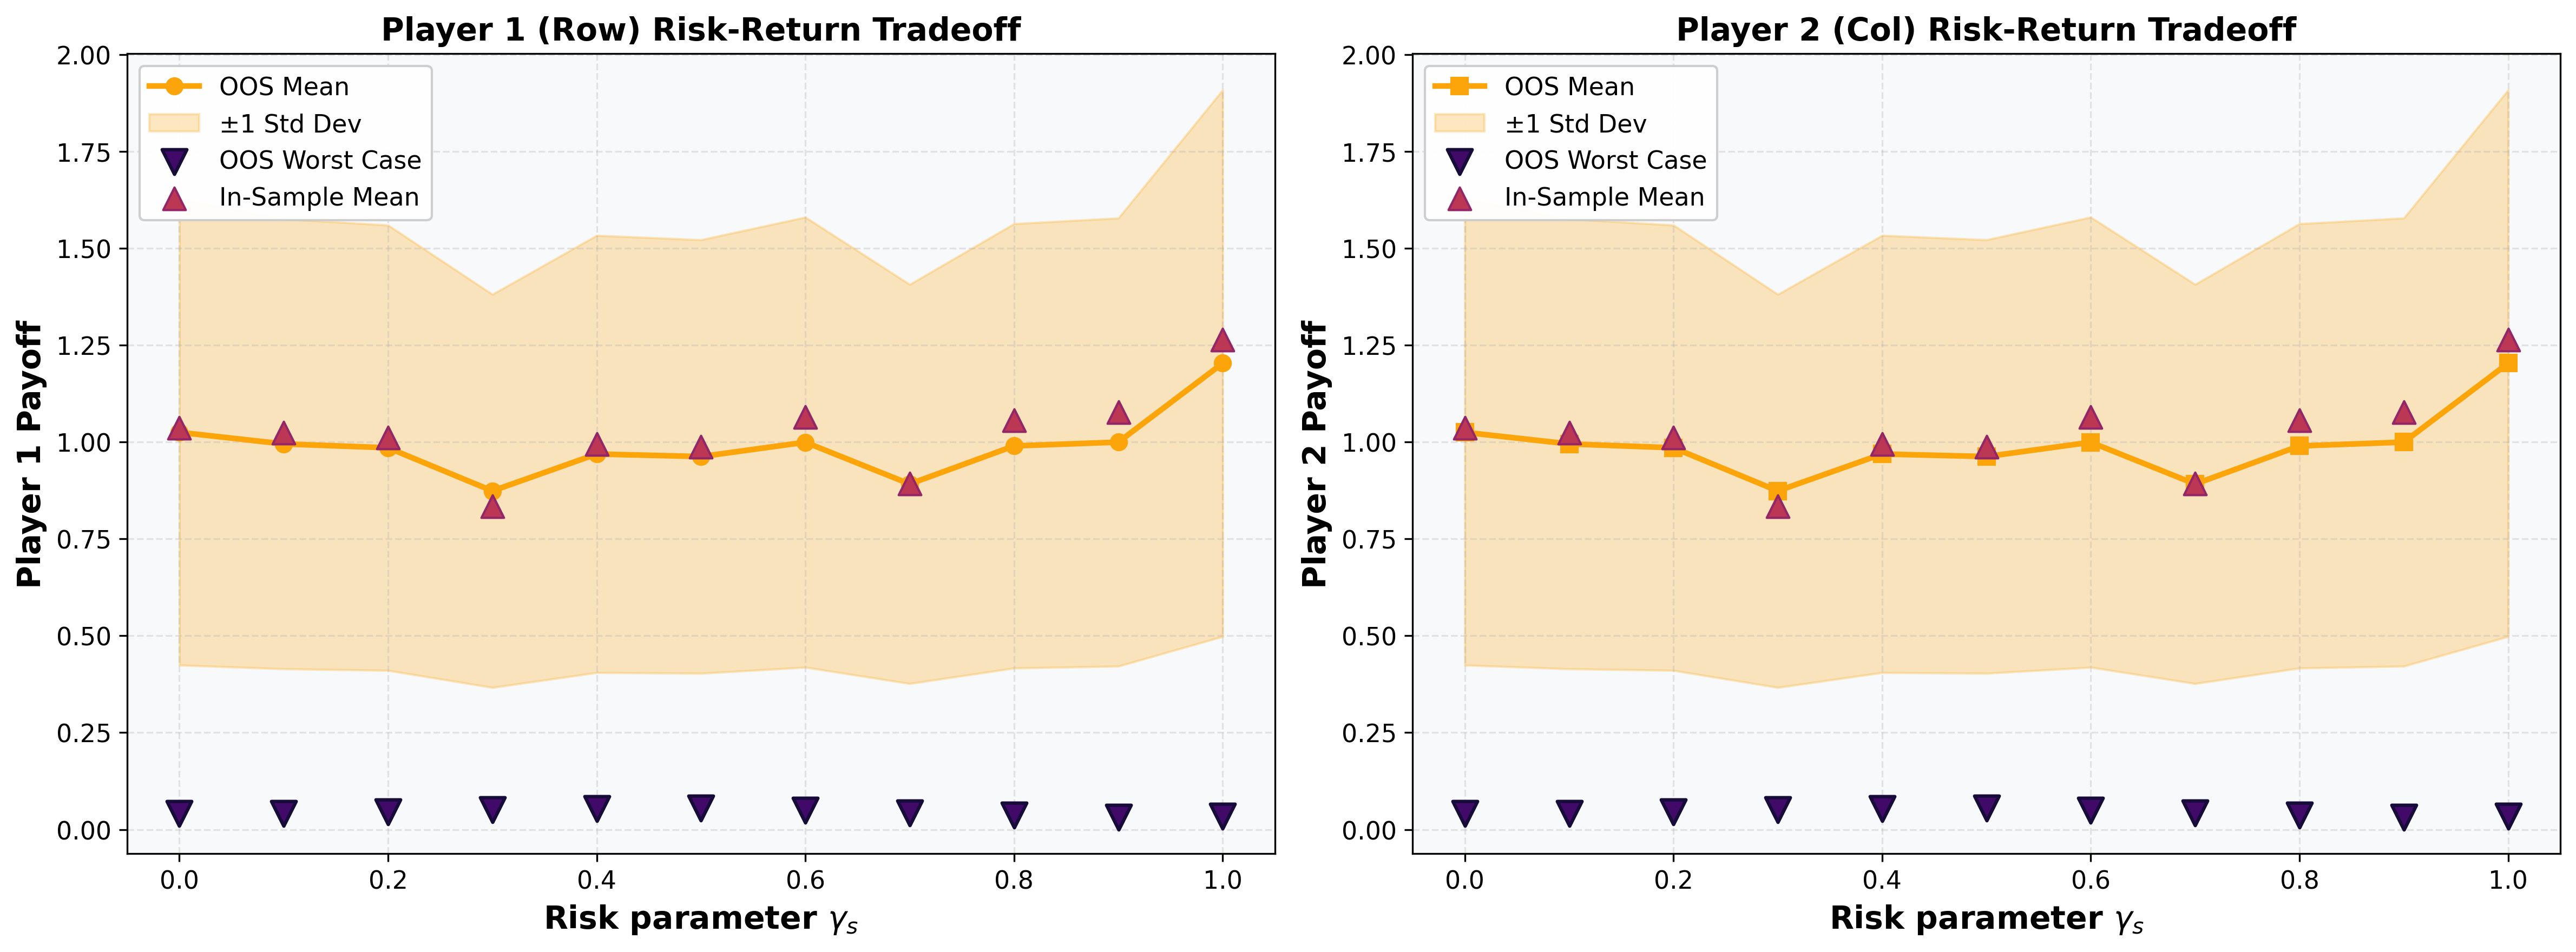


PRISONER'S DILEMMA: KEY RESULTS

OOS Performance Summary:
  γ=0.0 (Risk-neutral):      Mean₁=1.025, Mean₂=1.025
  γ=1.0 (Risk-averse):       Mean₁=1.204, Mean₂=1.204

Worst-case vulnerability (Minimum OOS Payoff):
  γ=0.0:  Min₁=0.042, Min₂=0.042
  γ=1.0:  Min₁=0.034, Min₂=0.034

Standard Deviation (OOS Volatility):
  γ=0.0:  Std₁=0.601, Std₂=0.601
  γ=1.0:  Std₁=0.706, Std₂=0.706


In [76]:
res_mean = res.groupby("gamma").mean().reset_index()
# Visualization: Prisoner's Dilemma Risk-Return Analysis
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
cmap = plt.cm.inferno

# Player 1 (row player)
ax1 = axes[0]
ax1.plot(
    res_mean["gamma"],
    res_mean["oos_mean1"],
    "o-",
    color=cmap(0.8),
    label="OOS Mean",
    linewidth=2.5,
    markersize=7,
)
ax1.fill_between(
    res_mean["gamma"],
    res_mean["oos_mean1"] - res_mean["oos_std1"],
    res_mean["oos_mean1"] + res_mean["oos_std1"],
    alpha=0.25,
    color=cmap(0.8),
    label="±1 Std Dev",
)
ax1.scatter(
    res_mean["gamma"],
    res_mean["oos_min1"],
    color=cmap(0.2),
    s=120,
    marker="v",
    label="OOS Worst Case",
    zorder=6,
    edgecolor=cmap(0.1),
    linewidth=1.5,
)
ax1.scatter(
    res_mean["gamma"],
    res_mean["in_sample_payoff1"],
    color=cmap(0.5),
    s=100,
    marker="^",
    label="In-Sample Mean",
    zorder=6,
    edgecolor=cmap(0.4),
    linewidth=1,
)
ax1.set_xlabel(r"Risk parameter $\gamma_s$", fontsize=14, fontweight="bold")
ax1.set_ylabel("Player 1 Payoff", fontsize=14, fontweight="bold")
ax1.set_title(
    "Player 1 (Row) Risk-Return Tradeoff",
    fontsize=14,
    fontweight="bold",
)
ax1.legend(fontsize=11, loc="upper left", framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle="--")
ax1.set_facecolor("#f8f9fa")

# Player 2 (column player)
ax2 = axes[1]
ax2.plot(
    res_mean["gamma"],
    res_mean["oos_mean2"],
    "s-",
    color=cmap(0.8),
    label="OOS Mean",
    linewidth=2.5,
    markersize=7,
)
ax2.fill_between(
    res_mean["gamma"],
    res_mean["oos_mean2"] - res_mean["oos_std2"],
    res_mean["oos_mean2"] + res_mean["oos_std2"],
    alpha=0.25,
    color=cmap(0.8),
    label="±1 Std Dev",
)
ax2.scatter(
    res_mean["gamma"],
    res_mean["oos_min2"],
    color=cmap(0.2),
    s=120,
    marker="v",
    label="OOS Worst Case",
    zorder=6,
    edgecolor=cmap(0.1),
    linewidth=1.5,
)
ax2.scatter(
    res_mean["gamma"],
    res_mean["in_sample_payoff2"],
    color=cmap(0.5),
    s=100,
    marker="^",
    label="In-Sample Mean",
    zorder=6,
    edgecolor=cmap(0.4),
    linewidth=1,
)
ax2.set_xlabel(r"Risk parameter $\gamma_s$", fontsize=14, fontweight="bold")
ax2.set_ylabel("Player 2 Payoff", fontsize=14, fontweight="bold")
ax2.set_title(
    "Player 2 (Col) Risk-Return Tradeoff",
    fontsize=14,
    fontweight="bold",
)
ax2.legend(fontsize=11, loc="upper left", framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()

# Print key statistics
print("\n" + "=" * 70)
print("PRISONER'S DILEMMA: KEY RESULTS")
print("=" * 70)
print("\nOOS Performance Summary:")
print(
    f"  γ=0.0 (Risk-neutral):      Mean₁={res_mean.loc[res_mean['gamma']==0.0, 'oos_mean1'].values[0]:.3f}, Mean₂={res_mean.loc[res_mean['gamma']==0.0, 'oos_mean2'].values[0]:.3f}"
)
print(
    f"  γ=1.0 (Risk-averse):       Mean₁={res_mean.loc[res_mean['gamma']==1.0, 'oos_mean1'].values[0]:.3f}, Mean₂={res_mean.loc[res_mean['gamma']==1.0, 'oos_mean2'].values[0]:.3f}"
)
print(f"\nWorst-case vulnerability (Minimum OOS Payoff):")
print(
    f"  γ=0.0:  Min₁={res_mean.loc[res_mean['gamma']==0.0, 'oos_min1'].values[0]:.3f}, Min₂={res_mean.loc[res_mean['gamma']==0.0, 'oos_min2'].values[0]:.3f}"
)
print(
    f"  γ=1.0:  Min₁={res_mean.loc[res_mean['gamma']==1.0, 'oos_min1'].values[0]:.3f}, Min₂={res_mean.loc[res_mean['gamma']==1.0, 'oos_min2'].values[0]:.3f}"
)
print(f"\nStandard Deviation (OOS Volatility):")
print(
    f"  γ=0.0:  Std₁={res_mean.loc[res_mean['gamma']==0.0, 'oos_std1'].values[0]:.3f}, Std₂={res_mean.loc[res_mean['gamma']==0.0, 'oos_std2'].values[0]:.3f}"
)
print(
    f"  γ=1.0:  Std₁={res_mean.loc[res_mean['gamma']==1.0, 'oos_std1'].values[0]:.3f}, Std₂={res_mean.loc[res_mean['gamma']==1.0, 'oos_std2'].values[0]:.3f}"
)
print("=" * 70)

## Non zero-sum game

In [523]:
import numpy as np

small_sample_size = 5
n_small_sample = 100
n_large_sample = 10000

rng = np.random.default_rng(444)
scenarios = rng.binomial(1, 0.5, (n_small_sample, small_sample_size))
large_n = rng.binomial(1, 0.5, n_large_sample)

p_hat_counts = np.array(
    [
        (scenarios == 0).sum(axis=1),
        (scenarios == 1).sum(axis=1),
    ]
).transpose()
p_hat = p_hat_counts / small_sample_size


def payoff_matrices(state):

    if state == 0:
        return np.array([[2, 0], [2, -1]])
    else:
        return np.array([[0, 0], [2, -1]])


A_payoffs = [payoff_matrices(i) for i in range(2)]
B_payoff = np.array([[3, 2], [0, 1]])
B_payoffs = [B_payoff for _ in range(2)]

A_large_n = [payoff_matrices(s) for s in large_n]
B_large_n = [B_payoff for _ in range(n_large_sample)]
A_payoffs, B_payoffs

([array([[ 2,  0],
         [ 2, -1]]),
  array([[ 0,  0],
         [ 2, -1]])],
 [array([[3, 2],
         [0, 1]]),
  array([[3, 2],
         [0, 1]])])

In [525]:
alpha = 1e-7
gamma = 0.5

res = path_MCP_game_result_cVar(
    A_payoffs, B_payoffs, gamma=gamma, alpha=alpha, p=[0.5, 0.5], verbose=True
)
print("\nAnalytical calculation for alpha < 0.5\n")
# alpha < 0.5
y = 1 / (2 + gamma)
print(f"{y=}")
z = 3 / (2 * (2 + gamma)) - 0.5
print(f"{z=}")
rew = (1 - gamma) / (2 + gamma)
print(f"Expected Reward = {rew}")

# alpha > 0.5
print("\nAnalytical calculation for alpha > 0.5\n")
y = alpha / (2 * alpha + gamma * (1 - alpha))
print(f"{y=}")
z = 5 / 2 * y - 0.5
print(f"{z=}")
rew = y * (2 + (alpha - 1) / (2 * alpha) * gamma) - 0.5
print(f"Expected Reward = {rew}")
# rew = (4 * alpha + (alpha - 1) * gamma) / (4 * alpha + 2 * gamma * (1 - alpha)) - 0.5
# print(f"Expected Reward = {rew}")

res

==================================================PATH Result==================================================
x* = [0.5 0.5]  y* = [0.4 0.6]
alpha1 = 0.2  alpha2 = 1.5
p=[0.5, 0.5]

Analytical calculation for alpha < 0.5

y=0.4
z=0.09999999999999998
Expected Reward = 0.2

Analytical calculation for alpha > 0.5

y=1.99999940000018e-07
z=-0.49999950000015
Expected Reward = -0.9999994000001802


{'x': array([0.5, 0.5]),
 'y': array([0.4, 0.6]),
 'alpha': 1e-07,
 'alpha1': 0.2,
 'alpha2': 1.5,
 'lam1': array([0. , 0.5]),
 'nu1': array([0., 0.]),
 'z1': 0.10000000000000003,
 'lam2': array([0. , 0.5]),
 'nu2': array([0., 0.]),
 'z2': 1.5}

In [526]:
# Summary statistics
print("\n" + "=" * 70)
print("ANALYTICAL CVaR GAME: PAYOFF SURFACE ANALYSIS")
print("=" * 70)
print(f"\nGamma range: [{gamma_lin_fine.min():.3f}, {gamma_lin_fine.max():.3f}]")
print(f"Alpha range: [{alpha_lin_fine.min():.6f}, {alpha_lin_fine.max():.3f}]")
print(f"\nStrategy y*: Min={Y.min():.4f}, Max={Y.max():.4f}")
print(f"VaR threshold z*: Min={Z.min():.4f}, Max={Z.max():.4f}")
print(f"Expected Reward: Min={Reward.min():.4f}, Max={Reward.max():.4f}")
print("\nPhase transition: α = 0.5")
print("  α < 0.5: y* and reward depend only on γ")
print("  α > 0.5: y* and reward depend on both γ and α")
print("=" * 70)


ANALYTICAL CVaR GAME: PAYOFF SURFACE ANALYSIS

Gamma range: [0.000, 1.000]
Alpha range: [0.000000, 1.000]

Strategy y*: Min=0.3333, Max=0.5000
VaR threshold z*: Min=0.0000, Max=0.7500
Expected Reward: Min=0.0000, Max=0.5000

Phase transition: α = 0.5
  α < 0.5: y* and reward depend only on γ
  α > 0.5: y* and reward depend on both γ and α


/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/4021986330.py:6: RuntimeWarning: invalid value encountered in divide
  Y = np.where(Alpha < 0.5, 1.0 / (2 + Gamma), Alpha / (2 * Alpha + Gamma * (1 - Alpha)))
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/4021986330.py:11: RuntimeWarning: invalid value encountered in divide
  (4 * Alpha + (Alpha - 1) * Gamma) / (4 * Alpha + 2 * Gamma * (1 - Alpha)) - 0.5,
/var/folders/bq/rft0jdgx1kj30hkw43yb62wm0000gn/T/ipykernel_76789/4021986330.py:16: RuntimeWarning: invalid value encountered in divide
  Alpha**2 / (4 * (2 * Alpha + Gamma * (1 - Alpha)) ** 2),


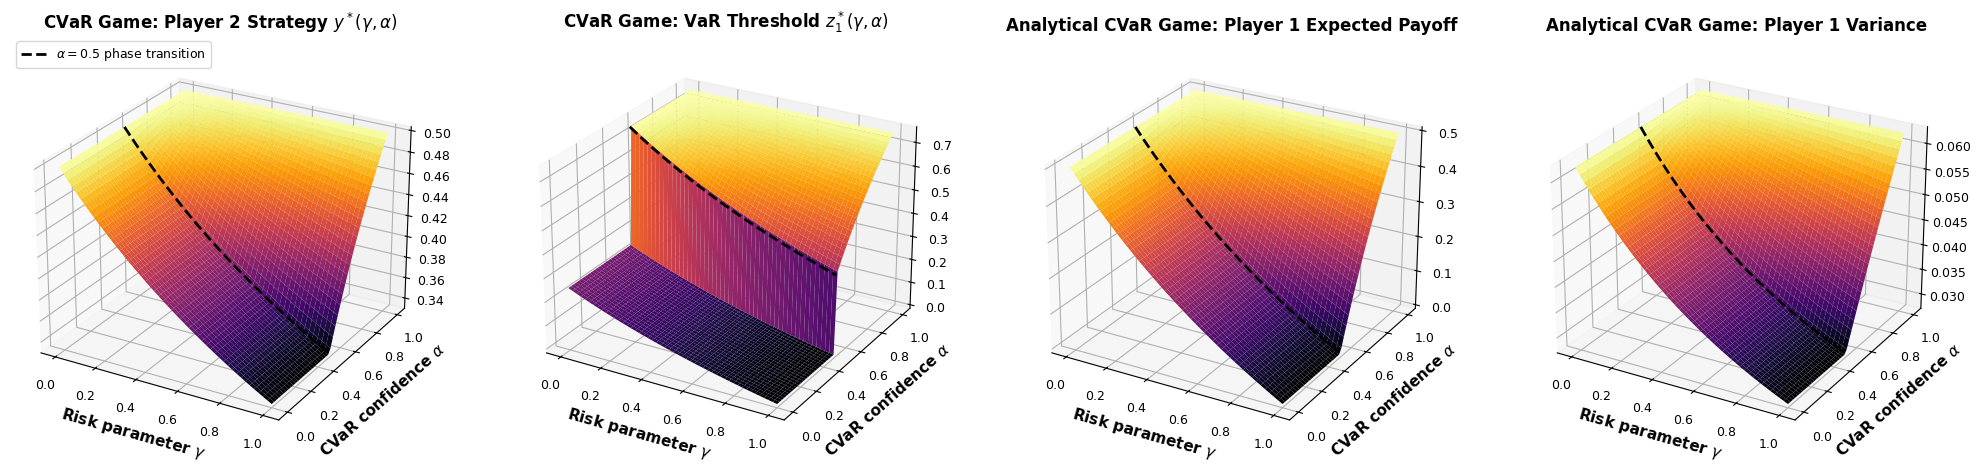

In [527]:
# Combined 3D subplots in a single row
alpha_lin_fine = np.linspace(0, 1.0, 50)
gamma_lin_fine = np.linspace(0, 1.0, 50)
Gamma, Alpha = np.meshgrid(gamma_lin_fine, alpha_lin_fine)

Y = np.where(Alpha < 0.5, 1.0 / (2 + Gamma), Alpha / (2 * Alpha + Gamma * (1 - Alpha)))
Z = np.where(Alpha < 0.5, 3.0 / (2 * (2 + Gamma)) - 0.5, 5.0 / 2 * Y - 0.5)
Reward = np.where(
    Alpha < 0.5,
    (1 - Gamma) / (2 + Gamma),
    (4 * Alpha + (Alpha - 1) * Gamma) / (4 * Alpha + 2 * Gamma * (1 - Alpha)) - 0.5,
)
Var = np.where(
    Alpha < 0.5,
    1 / (4 * (2 + Gamma) ** 2),
    Alpha**2 / (4 * (2 * Alpha + Gamma * (1 - Alpha)) ** 2),
)

plt.rcParams.update(
    {"font.size": 9, "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9}
)

fig, axs = plt.subplots(1, 4, figsize=(25, 6), subplot_kw={"projection": "3d"})

# shared dashed line data at alpha = 0.5
gamma_line = Gamma[0, :]
alpha_target = 0.5

# Plot 1: Strategy y
surf1 = axs[0].plot_surface(
    Gamma, Alpha, Y, cmap="inferno", linewidth=0, antialiased=True
)
axs[0].set_xlabel(r"Risk parameter $\gamma$", fontsize=11, fontweight="bold")
axs[0].set_ylabel(r"CVaR confidence $\alpha$", fontsize=11, fontweight="bold")
axs[0].set_title(
    r"CVaR Game: Player 2 Strategy $y^*(\gamma, \alpha)$",
    fontsize=12,
    fontweight="bold",
    pad=3,
)
y_line = 1 / (2 + gamma_line)
axs[0].plot(
    gamma_line,
    np.full_like(gamma_line, alpha_target),
    y_line,
    color="k",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label=r"$\alpha=0.5$ phase transition",
)
axs[0].legend(loc="upper left", fontsize=9)
axs[0].view_init(elev=25, azim=300)

# Plot 2: VaR threshold z
surf2 = axs[1].plot_surface(
    Gamma, Alpha, Z, cmap="inferno", linewidth=0, antialiased=True
)
axs[1].set_xlabel(r"Risk parameter $\gamma$", fontsize=11, fontweight="bold")
axs[1].set_ylabel(r"CVaR confidence $\alpha$", fontsize=11, fontweight="bold")
axs[1].set_title(
    r"CVaR Game: VaR Threshold $z_1^*(\gamma, \alpha)$",
    fontsize=12,
    fontweight="bold",
    pad=3,
)
z_line = alpha_target / (2 * alpha_target + gamma_line * (1 - alpha_target))
z_line = 5.0 / 2 * z_line - 0.5
axs[1].plot(
    gamma_line,
    np.full_like(gamma_line, alpha_target),
    z_line,
    color="k",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label=r"$\alpha=0.5$ phase transition",
)
axs[1].view_init(elev=25, azim=300)

# Plot 3: Expected reward
surf3 = axs[2].plot_surface(
    Gamma, Alpha, Reward, cmap="inferno", linewidth=0, antialiased=True
)
axs[2].set_xlabel(r"Risk parameter $\gamma$", fontsize=11, fontweight="bold")
axs[2].set_ylabel(r"CVaR confidence $\alpha$", fontsize=11, fontweight="bold")
axs[2].set_title(
    r"Analytical CVaR Game: Player 1 Expected Payoff",
    fontsize=12,
    fontweight="bold",
    pad=3,
)
reward_line = (4 * alpha_target + (alpha_target - 1) * gamma_line) / (
    4 * alpha_target + 2 * gamma_line * (1 - alpha_target)
) - 0.5
axs[2].plot(
    gamma_line,
    np.full_like(gamma_line, alpha_target),
    reward_line,
    color="k",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label=r"$\alpha=0.5$ phase transition",
)
axs[2].view_init(elev=25, azim=300)

# Plot 4: Variance
surf3 = axs[3].plot_surface(
    Gamma, Alpha, Var, cmap="inferno", linewidth=0, antialiased=True
)
axs[3].set_xlabel(r"Risk parameter $\gamma$", fontsize=11, fontweight="bold")
axs[3].set_ylabel(r"CVaR confidence $\alpha$", fontsize=11, fontweight="bold")
axs[3].set_title(
    r"Analytical CVaR Game: Player 1 Variance",
    fontsize=12,
    fontweight="bold",
    pad=3,
)
var_line = 1 / (4 * (2 + gamma_line) ** 2)

axs[3].plot(
    gamma_line,
    np.full_like(gamma_line, alpha_target),
    var_line,
    color="k",
    linestyle="--",
    linewidth=2,
    zorder=3,
    label=r"$\alpha=0.5$ phase transition",
)
axs[3].view_init(elev=25, azim=300)


plt.show()

### Fig 4

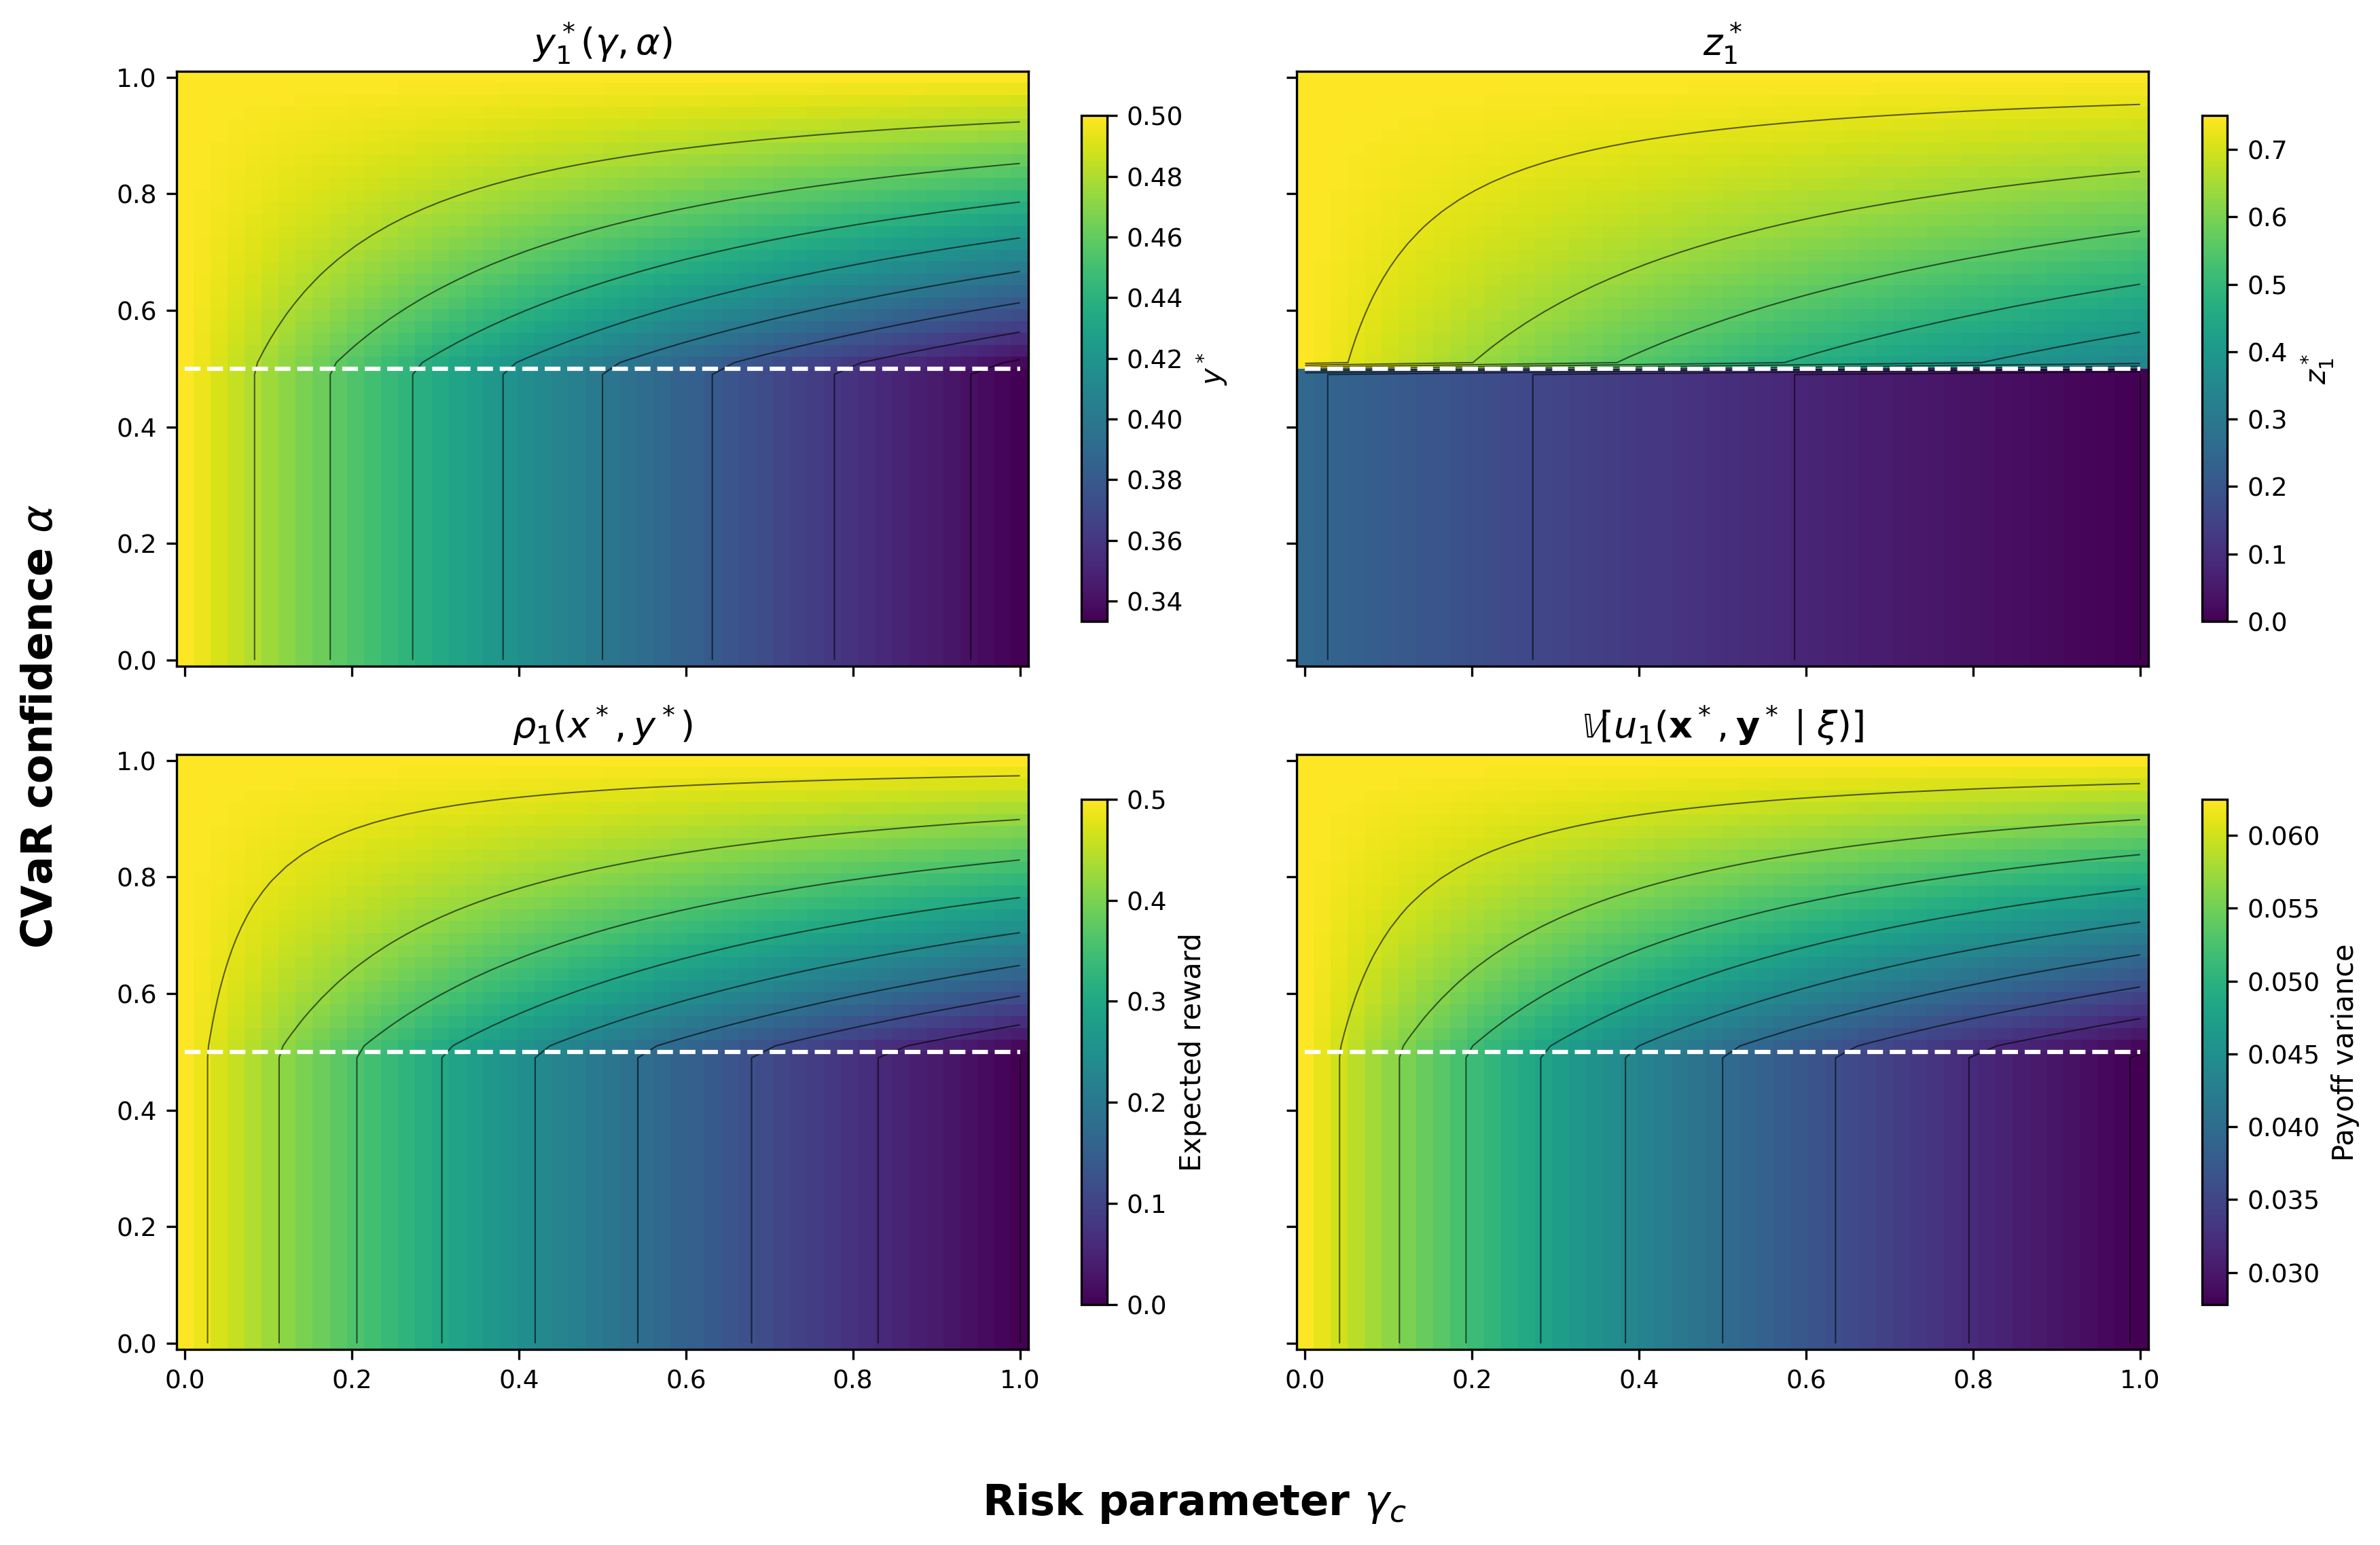

In [528]:
# Combined horizontal subplots with single shared x/y labels
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True, dpi=300)
cmap = "viridis"


# Strategy y* contour
CS = axs[0, 0].pcolormesh(gamma_vals, alpha_vals, Y, cmap=cmap, shading="auto")
axs[0, 0].set_title(r"$y_1^*(\gamma,\alpha)$", fontsize=13, fontweight="bold")
axs[0, 0].contour(
    gamma_vals, alpha_vals, Y, levels=8, colors="k", linewidths=0.5, alpha=0.6
)
axs[0, 0].plot(
    gamma_vals,
    0.5 * np.ones_like(gamma_vals),
    color="white",
    linestyle="--",
    linewidth=1.5,
)
cbar0 = fig.colorbar(CS, ax=axs[0, 0], shrink=0.85)
cbar0.set_label(r"$y^*$", fontsize=10)

# Expected Reward heatmap
pcm0 = axs[1, 0].pcolormesh(gamma_vals, alpha_vals, Reward, cmap=cmap, shading="auto")
axs[1, 0].contour(
    gamma_vals, alpha_vals, Reward, levels=8, colors="k", linewidths=0.5, alpha=0.6
)
axs[1, 0].set_title(r"$\rho_1(x^*, y^*)$", fontsize=13, fontweight="bold")
axs[1, 0].plot(
    gamma_vals,
    0.5 * np.ones_like(gamma_vals),
    color="white",
    linestyle="--",
    linewidth=1.5,
)
cbar1 = fig.colorbar(pcm0, ax=axs[1, 0], shrink=0.85)
cbar1.set_label("Expected reward", fontsize=10)

# VaR z*
pcm2 = axs[0, 1].pcolormesh(gamma_vals, alpha_vals, Z, cmap=cmap, shading="auto")
axs[0, 1].set_title(r"$z_1^*$", fontsize=13, fontweight="bold")
axs[0, 1].contour(
    gamma_vals, alpha_vals, Z, levels=10, colors="k", linewidths=0.5, alpha=0.6
)
axs[0, 1].plot(
    gamma_vals,
    0.5 * np.ones_like(gamma_vals),
    color="white",
    linestyle="--",
    linewidth=1.5,
)
cbar2 = fig.colorbar(pcm2, ax=axs[0, 1], shrink=0.85)
cbar2.set_label(r"$z_1^*$", fontsize=10)

# Var payoff
pcm3 = axs[1, 1].pcolormesh(gamma_vals, alpha_vals, Var, cmap=cmap, shading="auto")
axs[1, 1].set_title(
    r"$\mathbb{V}[u_1(\mathbf{x}^*, \mathbf{y}^* \mid \xi)]$",
    fontsize=13,
    fontweight="bold",
)
axs[1, 1].contour(
    gamma_vals, alpha_vals, Var, levels=10, colors="k", linewidths=0.5, alpha=0.6
)
axs[1, 1].plot(
    gamma_vals,
    0.5 * np.ones_like(gamma_vals),
    color="white",
    linestyle="--",
    linewidth=1.5,
)
cbar2 = fig.colorbar(pcm3, ax=axs[1, 1], shrink=0.85)
cbar2.set_label(r"Payoff variance", fontsize=10)


# Single shared axis labels
fig.supxlabel(r"Risk parameter $\gamma_c$", fontsize=15, fontweight="bold")
fig.supylabel(r"CVaR confidence $\alpha$", fontsize=15, fontweight="bold")

plt.tight_layout(rect=[0.02, 0.03, 1, 0.95])
plt.show()

## Scalability experiments

### MSD

In [ ]:
import time
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

# Experiment settings
gamma = 0.5
eps = 1e-2
K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
seed_base = 123


def support_sizes(K, n):
    kappa = min(n, max(2, int(np.ceil(np.sqrt(n)))))
    tau = min(K, max(5, int(np.ceil(np.sqrt(K)))))
    return kappa, tau


def run_one_instance(K, n, seed, gamma=0.5, eps=1e-2):
    A_list_samp, B_list_samp, p_samp = simulate_random_payoffs(
        K=K, n=n, seed=seed, dist="uniform", low=0.0, high=1.0
    )
    kappa, tau = support_sizes(K, n)

    # 1) Small-support search
    t0 = time.perf_counter()
    try:
        small_out = small_support_search_msd(
            A_list_samp,
            B_list_samp,
            p_samp,
            gamma,
            epsilon=eps,
            epsilon_scr=2 * eps / 3,
            kappa=kappa,
            tau=tau,
            max_candidates=1000,
            n_screen_starts=2,
            n_regret_starts=3,
            screen_maxiter=100,
            seed=seed,
            verbose=False,
        )
        small_time = time.perf_counter() - t0
        if small_out.get("success", False):
            small_success = True
            small_eta = float(small_out["certificate"]["eta"])
        else:
            small_success = False
            small_eta = float(
                small_out.get("best_regret", {})
                .get("certificate", {})
                .get("eta", np.nan)
            )
    except Exception as exc:
        small_time = time.perf_counter() - t0
        small_success = False
        small_eta = np.nan
        print(f"[small_support] K={K}, n={n}, seed={seed} failed: {exc}")

    # 2) Full MCP path solver
    t0 = time.perf_counter()
    try:
        mcp_out = path_MCP_game_result(
            A_list_samp,
            B_list_samp,
            gamma,
            p_samp,
            verbose=False,
            tee=False,
            fallback_solver=None,
        )
        mcp_time = time.perf_counter() - t0
        x = np.asarray(mcp_out["x"], dtype=float)
        y = np.asarray(mcp_out["y"], dtype=float)

        feasible = (
            np.all(np.isfinite(x))
            and np.all(np.isfinite(y))
            and np.isclose(x.sum(), 1.0, atol=1e-6)
            and np.isclose(y.sum(), 1.0, atol=1e-6)
        )
        mcp_success = bool(feasible)

        if mcp_success:
            try:
                regret = full_msd_regret(
                    A_list_samp, B_list_samp, p_samp, gamma, x, y, n_starts=3, seed=seed
                )
                mcp_eta = float(regret["eta"])
                mcp_success = bool(feasible and np.isfinite(mcp_eta) and mcp_eta <= eps)
            except Exception:
                mcp_eta = np.nan
        else:
            mcp_eta = np.nan
    except Exception as exc:
        mcp_time = time.perf_counter() - t0
        mcp_success = False
        mcp_eta = np.nan
        print(f"[path_MCP] K={K}, n={n}, seed={seed} failed: {exc}")

    return {
        "K": K,
        "n": n,
        "seed": seed,
        "small_time_s": small_time,
        "small_success": small_success,
        "small_eta": small_eta,
        "mcp_time_s": mcp_time,
        "mcp_success": mcp_success,
        "mcp_eta": mcp_eta,
    }


# Run grid search
rows = []
n_rep = 20
for K in tqdm(K_grid, desc="K grid"):
    for n in tqdm(n_grid, leave=False, desc=f"K={K}"):
        for rep in tqdm(range(n_rep), leave=False, desc=f"K={K}, n={n} reps"):
            rows.append(
                run_one_instance(K, n, seed=seed_base + 10_000 * K + 100 * n + rep)
            )
            succ_runs = [
                x
                for x in rows
                if x["mcp_success"]
                and x["small_succ_runs"]
                and (x["K"] == K)
                and (x["n"] == n)
            ]
            if succ_runs == 5:
                break

exp_results = pd.DataFrame(rows)
exp_results.to_csv("scalabilityExperimentMSDv2.csv")

K grid:   0%|          | 0/5 [00:00<?, ?it/s]

K=5:   0%|          | 0/4 [00:00<?, ?it/s]

K=5, n=5 reps:   0%|          | 0/5 [00:00<?, ?it/s]

Complementarity programme failed because: Cannot load a SolverResults object with bad status: error


K=5, n=10 reps:   0%|          | 0/5 [00:00<?, ?it/s]

...

Solver status: warning
Termination condition: maxIterations
Solver message: Path 5.0.05\x3a Cumulative iteration limit.; 56 iterations (0 for crash); 101783 pivots.; 108 function, 57 gradient evaluations.
Solver result object: 
Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 4042
  Sense: unknown
Solver: 
- Status: warning
  Message: Path 5.0.05\x3a Cumulative iteration limit.; 56 iterations (0 for crash); 101783 pivots.; 108 function, 57 gradient evaluations.
  Termination condition: maxIterations
  Id: 401
  Error rc: 0
  Time: 7.672601222991943
Solution: 
- number of solutions: 1
  number of solutions displayed: 1
- Status: stoppedByLimit
  Message: Path 5.0.05\x3a Cumulative iteration limit.; 56 iterations (0 for crash); 101783 pivots.; 108 function, 57 gradient evaluations.
  Objective: No values
  Variable:
    v0:
      Value: 0.07398379176298131
    v1:
      Value: 0.07499664175802291
    v10:
     

K=500, n=20 reps:   0%|          | 0/5 [00:00<?, ?it/s]

Solver status: warning
Termination condition: maxIterations
Solver message: Path 5.0.05\x3a Cumulative iteration limit.; 59 iterations (0 for crash); 100036 pivots.; 145 function, 61 gradient evaluations.
Solver result object: 
Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 4082
  Sense: unknown
Solver: 
- Status: warning
  Message: Path 5.0.05\x3a Cumulative iteration limit.; 59 iterations (0 for crash); 100036 pivots.; 145 function, 61 gradient evaluations.
  Termination condition: maxIterations
  Id: 401
  Error rc: 0
  Time: 23.259785175323486
Solution: 
- number of solutions: 1
  number of solutions displayed: 1
- Status: stoppedByLimit
  Message: Path 5.0.05\x3a Cumulative iteration limit.; 59 iterations (0 for crash); 100036 pivots.; 145 function, 61 gradient evaluations.
  Objective: No values
  Variable:
    v0:
      Value: 0.04595041137998316
    v1:
      Value: 0.04538533454221666
    v10:
    

K=500, n=50 reps:   0%|          | 0/5 [00:00<?, ?it/s]

Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error
Complementarity programme failed because: Cannot load a SolverResults object with bad status: error


In [66]:
display(exp_results)
plot_df = exp_results.copy()

plot_df["method_small"] = "small_support"
plot_df["method_mcp"] = "path_MCP"
plot_df["problem_size"] = plot_df["K"] * plot_df["n"] * plot_df["n"]

plot_df[["kappa", "tau"]] = plot_df.apply(
    lambda r: pd.Series(support_sizes(int(r["K"]), int(r["n"]))),
    axis=1,
)

summary = plot_df.groupby(["K", "n", "kappa", "tau"], as_index=False).agg(
    reps=("seed", "count"),
    problem_size=("problem_size", "first"),
    small_success_rate=("small_success", "mean"),
    mcp_success_rate=("mcp_success", "mean"),
    small_time_median=("small_time_s", "median"),
    mcp_time_median=("mcp_time_s", "median"),
    small_time_q25=("small_time_s", lambda x: x.quantile(0.25)),
    small_time_q75=("small_time_s", lambda x: x.quantile(0.75)),
    mcp_time_q25=("mcp_time_s", lambda x: x.quantile(0.25)),
    mcp_time_q75=("mcp_time_s", lambda x: x.quantile(0.75)),
    small_eta_median=("small_eta", "median"),
    mcp_eta_median=("mcp_eta", "median"),
)

small_summary = (
    plot_df[plot_df["small_success"]]
    .groupby(["K", "n", "kappa", "tau"], as_index=False)
    .agg(
        reps_succ_small=("seed", "count"),
        problem_size=("problem_size", "first"),
        small_time_median=("small_time_s", "median"),
        small_time_q25=("small_time_s", lambda x: x.quantile(0.25)),
        small_time_q75=("small_time_s", lambda x: x.quantile(0.75)),
        small_eta_median=("small_eta", "median"),
    )
)

mcp_summary = (
    plot_df[plot_df["mcp_success"]]
    .groupby(["K", "n", "kappa", "tau"], as_index=False)
    .agg(
        reps_succ_mcp=("seed", "count"),
        problem_size=("problem_size", "first"),
        mcp_time_median=("mcp_time_s", "median"),
        mcp_time_q25=("mcp_time_s", lambda x: x.quantile(0.25)),
        mcp_time_q75=("mcp_time_s", lambda x: x.quantile(0.75)),
        mcp_eta_median=("mcp_eta", "median"),
    )
)

summary = mcp_summary.merge(
    small_summary, on=["K", "n", "kappa", "tau", "problem_size"], how="outer"
)
display(summary)

,K,n,seed,small_time_s,small_success,small_eta,mcp_time_s,mcp_success,mcp_eta
0,5,5,50623,0.397945,True,9.992007e-16,0.041875,True,2.220446e-16
1,5,5,50624,15.559300,False,3.165426e-02,0.041869,True,2.220446e-16
2,5,5,50625,15.673679,False,1.574235e-02,0.039238,True,3.330669e-16
3,5,5,50626,0.071832,True,3.996803e-15,0.080603,True,1.332268e-15
4,5,5,50627,0.465312,True,6.358347e-03,0.042136,True,1.554312e-15
...,...,...,...,...,...,...,...,...,...
95,500,50,5005123,225.942773,True,9.109641e-03,90.376192,False,NaN
96,500,50,5005124,194.885071,True,6.801053e-03,96.212567,False,NaN
97,500,50,5005125,34.938880,True,9.774254e-03,100.401584,False,NaN
98,500,50,5005126,253.062600,False,1.070703e-02,97.667275,False,NaN


,K,n,kappa,tau,reps_succ_mcp,problem_size,mcp_time_median,mcp_time_q25,mcp_time_q75,mcp_eta_median,reps_succ_small,small_time_median,small_time_q25,small_time_q75,small_eta_median
0,5,5,3,5,5.0,125,0.041875,0.041869,0.042136,3.330669e-16,3.0,0.397945,0.234888,0.431628,3.996803e-15
1,5,10,4,5,4.0,500,0.057542,0.054804,0.060859,8.326673e-16,3.0,0.920385,0.619702,0.966357,1.561889e-03
2,5,20,5,5,2.0,2000,0.121462,0.116509,0.126414,-1.240563e-12,2.0,8.038547,7.021052,9.056041,8.204011e-03
3,5,50,8,5,3.0,12500,0.618243,0.610150,0.645563,7.771561e-15,1.0,2.576478,2.576478,2.576478,8.771856e-03
4,10,5,3,5,5.0,250,0.056877,0.055429,0.067625,2.220446e-16,4.0,0.558738,0.219610,1.748538,5.694915e-03
5,10,10,4,5,5.0,1000,0.076519,0.074633,0.078025,5.551115e-16,3.0,1.308723,1.038922,2.023832,8.956380e-03
6,10,20,5,5,5.0,4000,0.283839,0.200518,0.286700,2.331468e-15,4.0,7.729239,5.385078,11.727628,6.266189e-03
7,10,50,8,5,1.0,25000,1.020344,1.020344,1.020344,2.442491e-15,NaN,NaN,NaN,NaN,NaN
8,30,5,3,6,5.0,750,0.077731,0.074373,0.101023,3.330669e-16,5.0,1.433986,1.178145,1.988979,7.253666e-03
9,30,10,4,6,3.0,3000,0.146600,0.143569,0.153911,2.220446e-16,5.0,3.417304,1.332691,14.972205,7.847497e-03


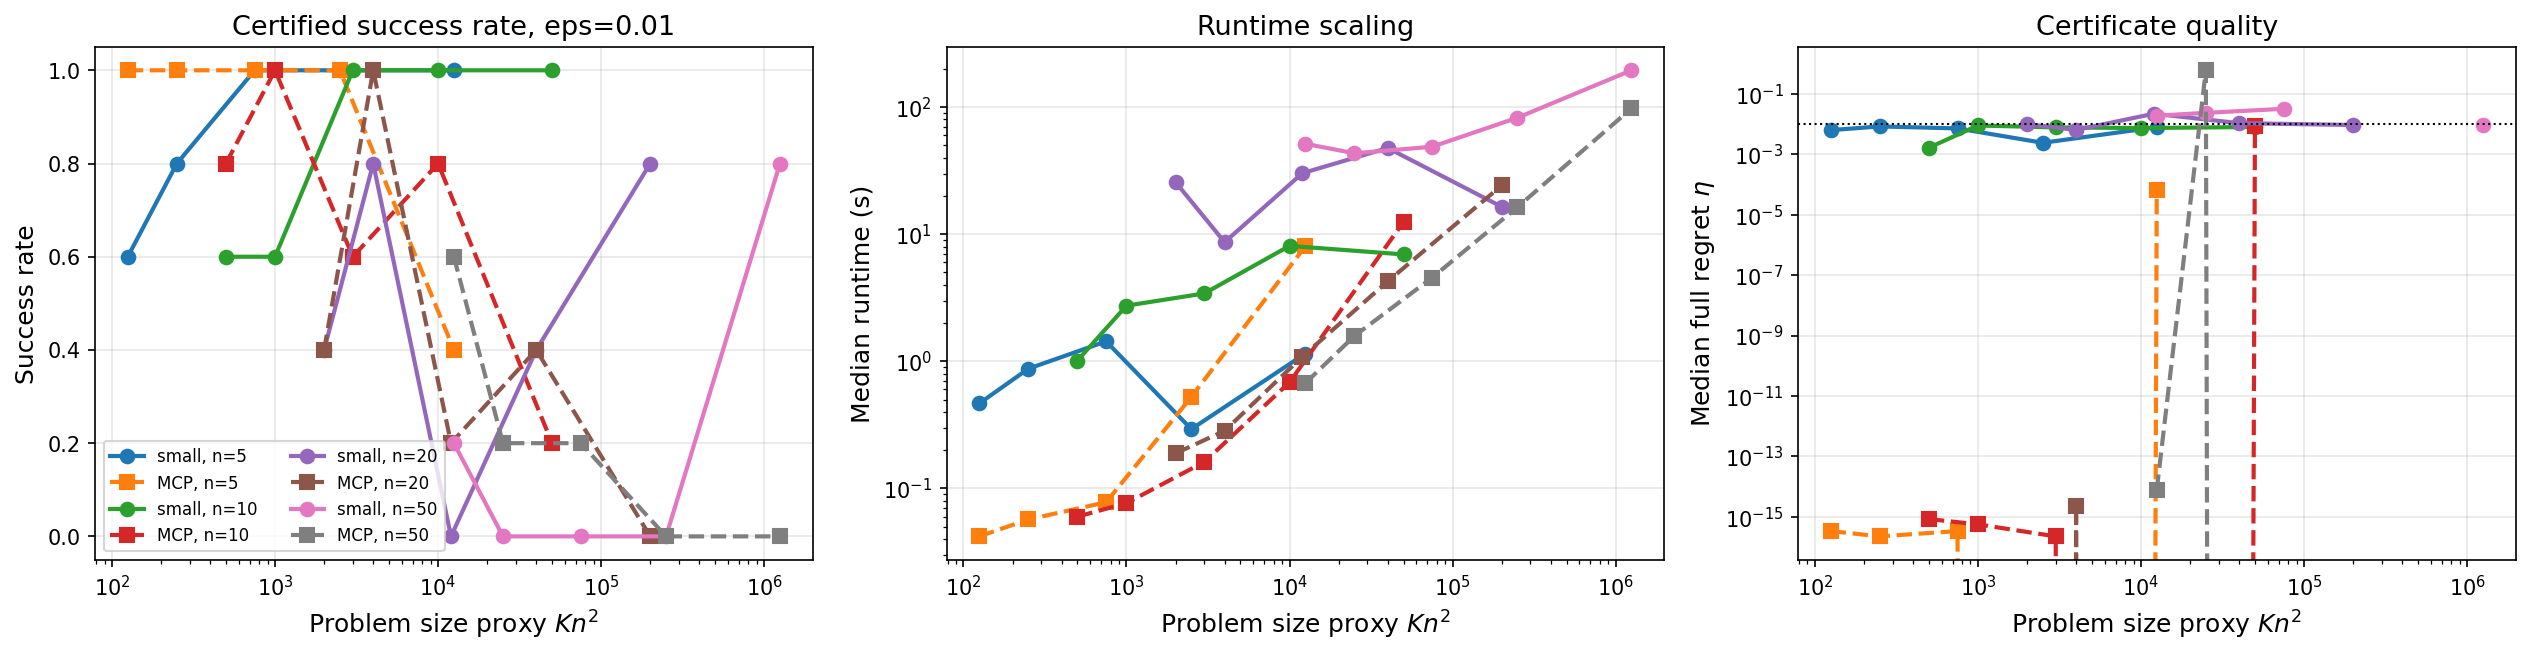

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), dpi=150)

# 1) Success rate vs problem size
for n in n_grid:
    s = summary[summary["n"] == n].sort_values("problem_size")
    axes[0].plot(
        s["problem_size"],
        s["small_success_rate"],
        "o-",
        label=f"small, n={n}",
    )
    axes[0].plot(
        s["problem_size"],
        s["mcp_success_rate"],
        "s--",
        label=f"MCP, n={n}",
    )

axes[0].set_xscale("log")
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlabel(r"Problem size proxy $K n^2$")
axes[0].set_ylabel("Success rate")
axes[0].set_title(f"Certified success rate, eps={eps:g}")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)

# 2) Median runtime vs problem size
for n in n_grid:
    s = summary[summary["n"] == n].sort_values("problem_size")
    axes[1].plot(
        s["problem_size"],
        s["small_time_median"],
        "o-",
        label=f"small, n={n}",
    )
    axes[1].plot(
        s["problem_size"],
        s["mcp_time_median"],
        "s--",
        label=f"MCP, n={n}",
    )

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"Problem size proxy $K n^2$")
axes[1].set_ylabel("Median runtime (s)")
axes[1].set_title("Runtime scaling")
axes[1].grid(alpha=0.3)

# 3) Median eta vs problem size
for n in n_grid:
    s = summary[summary["n"] == n].sort_values("problem_size")
    axes[2].plot(
        s["problem_size"],
        s["small_eta_median"],
        "o-",
        label=f"small, n={n}",
    )
    axes[2].plot(
        s["problem_size"],
        s["mcp_eta_median"],
        "s--",
        label=f"MCP, n={n}",
    )

axes[2].axhline(eps, color="black", linestyle=":", linewidth=1, label="eps")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel(r"Problem size proxy $K n^2$")
axes[2].set_ylabel(r"Median full regret $\eta$")
axes[2].set_title("Certificate quality")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
summary[summary["n"] == 50]

,K,n,kappa,tau,reps_succ_mcp,problem_size,mcp_time_median,mcp_time_q25,mcp_time_q75,mcp_eta_median,reps_succ_small,small_time_median,small_time_q25,small_time_q75,small_eta_median
3,5,50,8,5,3.0,12500,0.618243,0.610150,0.645563,7.771561e-15,1.0,2.576478,2.576478,2.576478,0.008772
7,10,50,8,5,1.0,25000,1.020344,1.020344,1.020344,2.442491e-15,NaN,NaN,NaN,NaN,NaN
11,30,50,8,6,1.0,75000,2.901774,2.901774,2.901774,-1.045930e-11,NaN,NaN,NaN,NaN,NaN
18,500,50,8,23,NaN,1250000,NaN,NaN,NaN,NaN,4.0,114.911976,30.862996,202.649497,0.008983


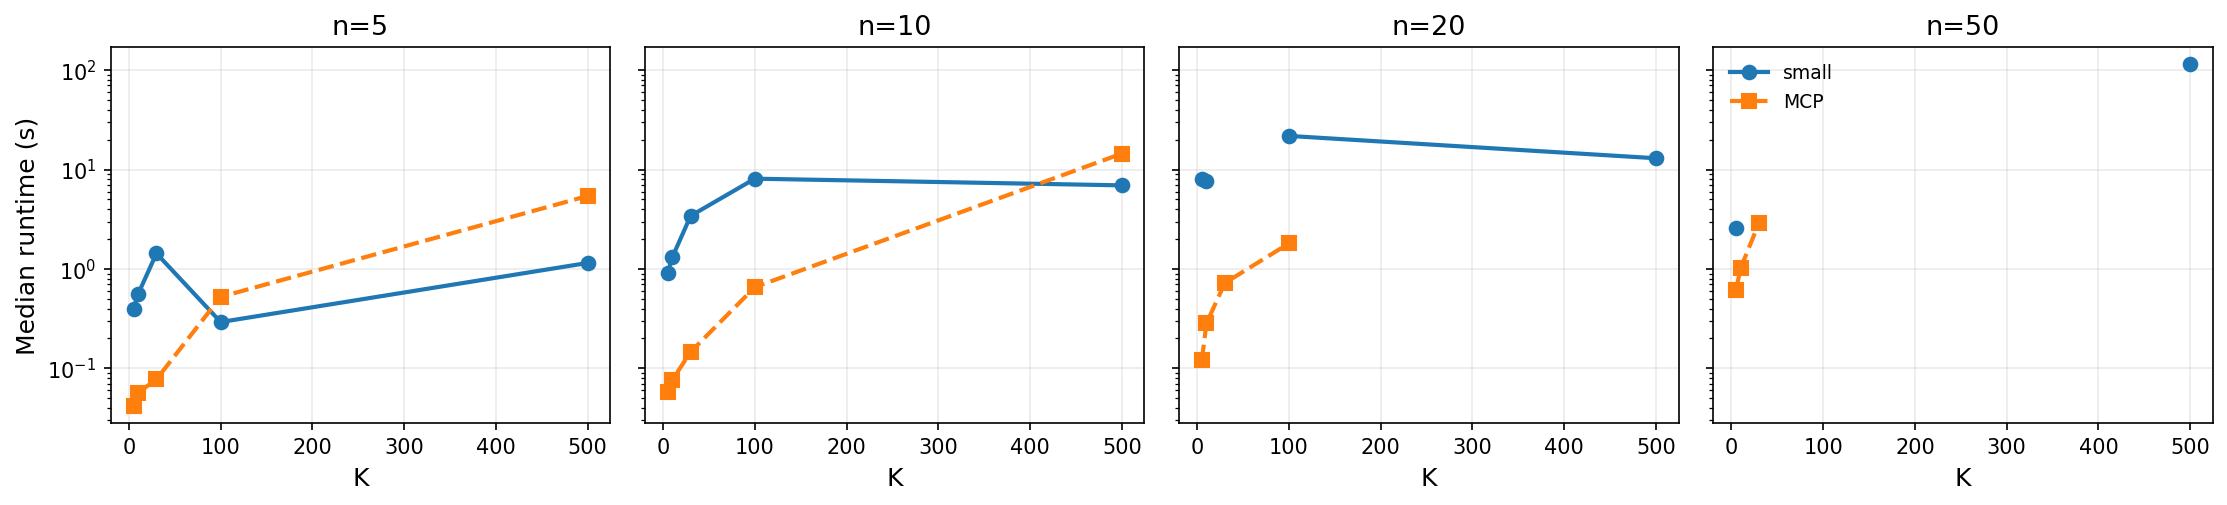

In [68]:
fig, axes = plt.subplots(1, len(n_grid), figsize=(15, 3.5), dpi=150, sharey=True)

for ax, n in zip(axes, n_grid):
    s = summary[summary["n"] == n].sort_values("K")

    ax.plot(s["K"], s["small_time_median"], "o-", label="small")
    ax.plot(s["K"], s["mcp_time_median"], "s--", label="MCP")
    ax.set_yscale("log")
    ax.set_title(f"n={n}")
    ax.set_xlabel("K")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Median runtime (s)")
axes[-1].legend(frameon=False)
plt.tight_layout()
plt.show()

In [34]:
display_cols = [
    "K",
    "n",
    "kappa",
    "tau",
    "reps",
    "problem_size",
    "small_success_rate",
    "mcp_success_rate",
    "small_time_median",
    "mcp_time_median",
    "small_eta_median",
    "mcp_eta_median",
]

summary[display_cols].sort_values(["K", "n"])

,K,n,kappa,tau,reps,problem_size,small_success_rate,mcp_success_rate,small_time_median,mcp_time_median,small_eta_median,mcp_eta_median
0,5,5,3,5,5,125,0.6,1.0,0.465312,0.041875,0.006358,3.330669e-16
1,5,10,4,5,5,500,0.6,0.8,1.012330,0.059845,0.001664,8.326673e-16
2,5,20,5,5,5,2000,0.4,0.4,25.664951,0.188411,0.010119,-1.240563e-12
3,5,50,8,5,5,12500,0.2,0.6,51.466733,0.672884,0.019185,7.771561e-15
4,10,5,3,5,5,250,0.8,1.0,0.873699,0.056877,0.008445,2.220446e-16
5,10,10,4,5,5,1000,0.6,1.0,2.738941,0.076519,0.009071,5.551115e-16
6,10,20,5,5,5,4000,0.8,1.0,8.652285,0.283839,0.006460,2.331468e-15
7,10,50,8,5,5,25000,0.0,0.2,43.314359,1.581976,0.023769,6.107224e-01
8,30,5,3,6,5,750,1.0,1.0,1.433986,0.077731,0.007254,3.330669e-16
9,30,10,4,6,5,3000,1.0,0.6,3.417304,0.161222,0.007847,2.220446e-16
